<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/%E8%87%AA%E7%84%B6%E8%A8%80%E8%AA%9E%E5%87%A6%E7%90%86%E2%91%A0%E3%82%B9%E3%83%8F%E3%82%9A%E3%83%A0%E3%83%A1%E3%83%BC%E3%83%AB%E5%88%A4%E5%AE%9A_%E8%AC%9B%E5%B8%AB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
1+1

2

# <font color=#0e89b2>0. ライブラリのインポート</font>

In [ ]:
#必要なライブラリのインストール
!pip install japanize_matplotlib
!pip install mecab-python3 unidic-lite
!pip install wordcloud
!pip install -q janome
!pip install gensim
!apt-get install fonts-ipafont-gothic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 35.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=3a9120293f4c0b2b32350f1031114c41af17af56c9376458426dc34e9df31a15
  Stored in directory: /root/.cache/pip/wheels/61/7a/6b/df1f79be9c59862525070e157e62b08eab8ece27c1b68fbb94
Successfully built japanize_matplotlib
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.7/581.7 kB 18.6 MB/s eta 0:00:00
  Created wheel for unidic-lite: filename=unidic_lite-1.0.8-py3-none-any.whl size=47658818 sha256=1e642456b5fa1803099eebe0cc3f2408bc9d0d8cde9ce1171d7b525d04dee601
  Stored in directory: /root/.cache/pip/wheels/89/e8/68/f9ac36b8cc6c8b3c96888cd57434abed96595d444f42243853
Successfully built unidic-lite
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.

In [ ]:
#データ分析ライブラリ
import numpy as np
import pandas as pd
import collections

#データ可視化ライブラリ
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

#機械学習ライブラリ
from sklearn.naive_bayes import GaussianNB
from sklearn import preprocessing
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

#自然言語処理ライブラリ
from janome.tokenizer import Tokenizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import re

#その他
from google.colab import files
from glob import iglob

%matplotlib inline

# <font color=#0e89b2>1. 自然言語処理とは</font>

## <font color=#0e89b2>1.1 自然言語とは</font>

自然言語とは、我々が日々話したり読み書きしている言葉のことです。<br>
<br>
「おはようございます」<br>
「明日は晴れると思います」<br>
<br>
プログラミング言語のような人工的に作られた言語と区別して、「自然言語」と呼ばれています。

## <font color=#0e89b2>1.2 自然言語処理とは</font>

自然言語をコンピュータに理解させたり、話させたりする技術のことを、自然言語処理(NLP)といいます。<br>
<br>
機械学習モデルは数学モデルなので、数値データはそのまま学習することが出来ましたが、<br>
自然言語はそのまま学習することが出来ません。<br>
<br>
ですので、<font color=#f27405>機械学習モデルで自然言語を扱う際には、数値データに変換</font>して処理することになります。<br>
この数値データへの変換の方法については多数種類があるので、この研修で実装しながら学んでいきます。

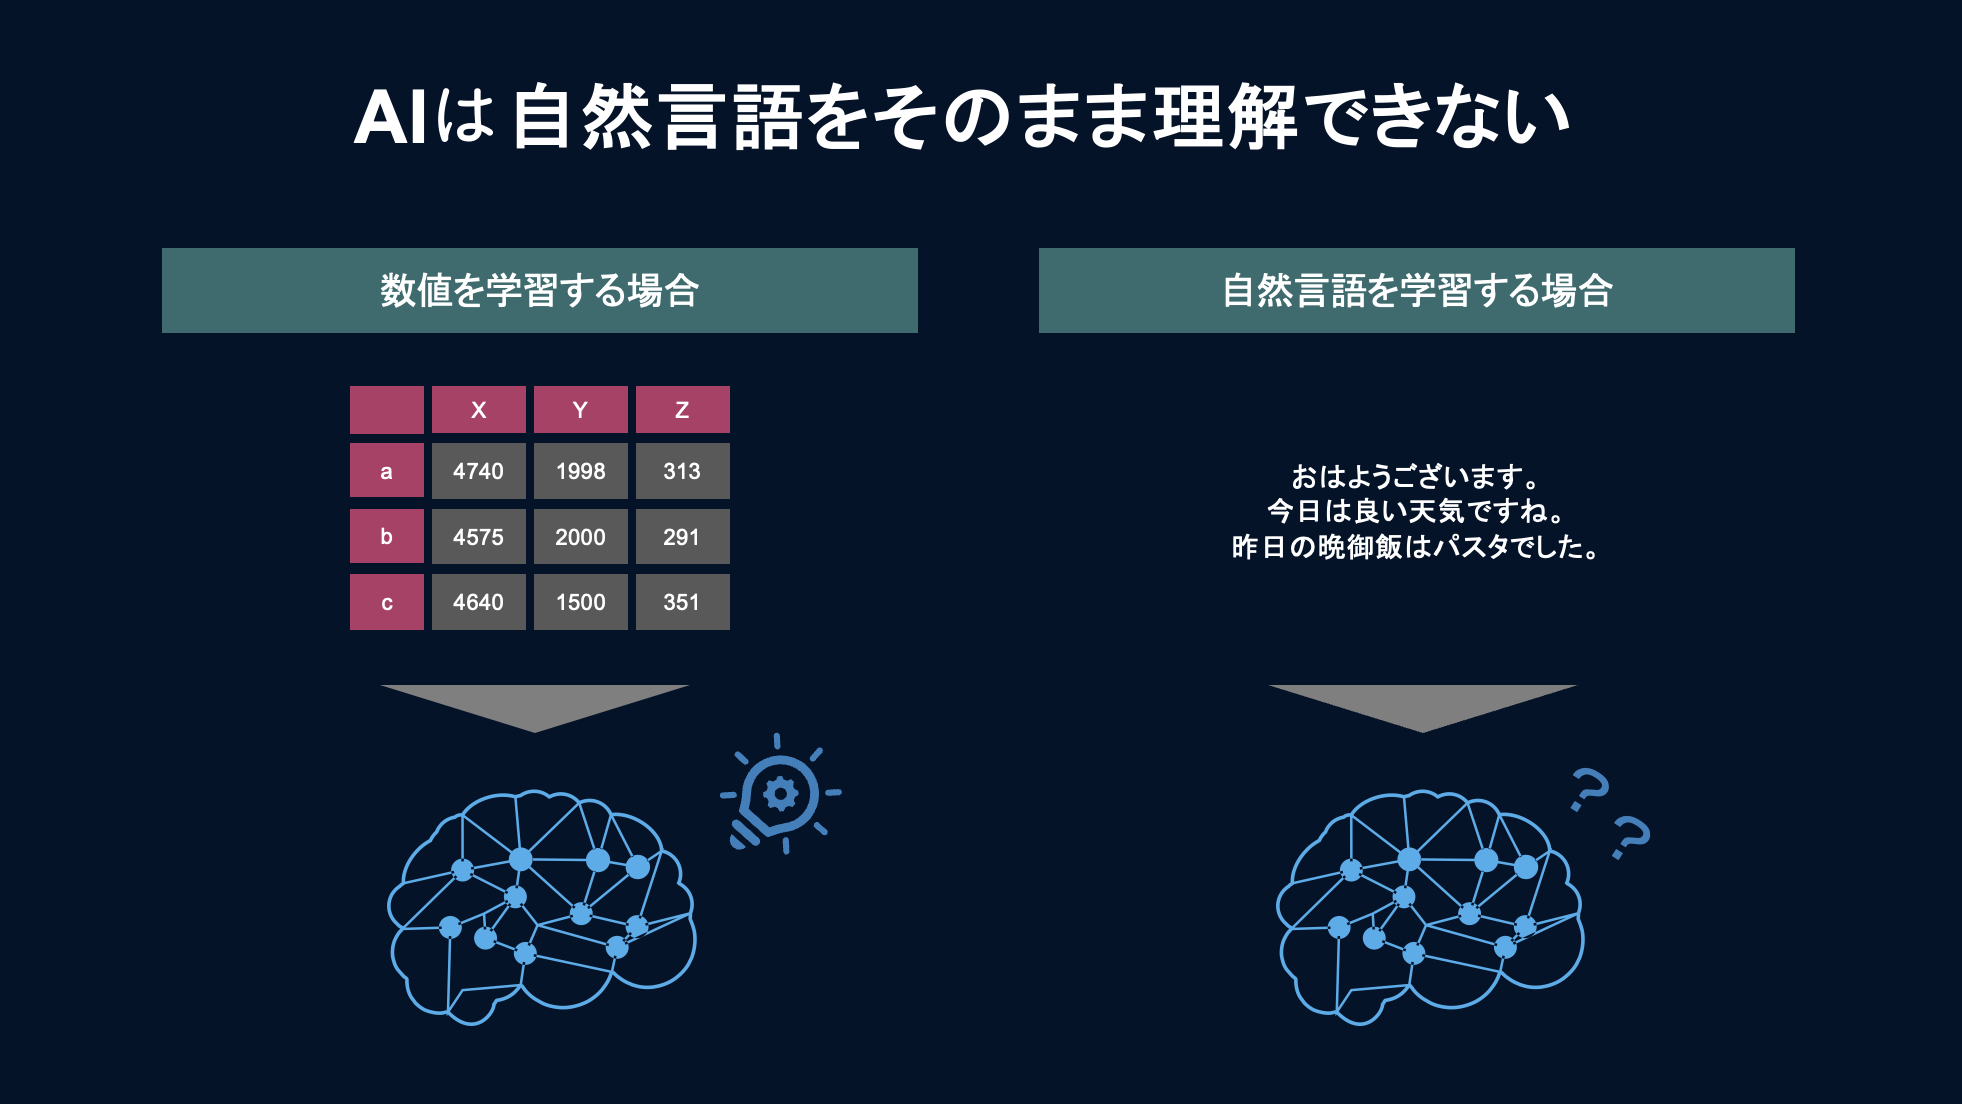

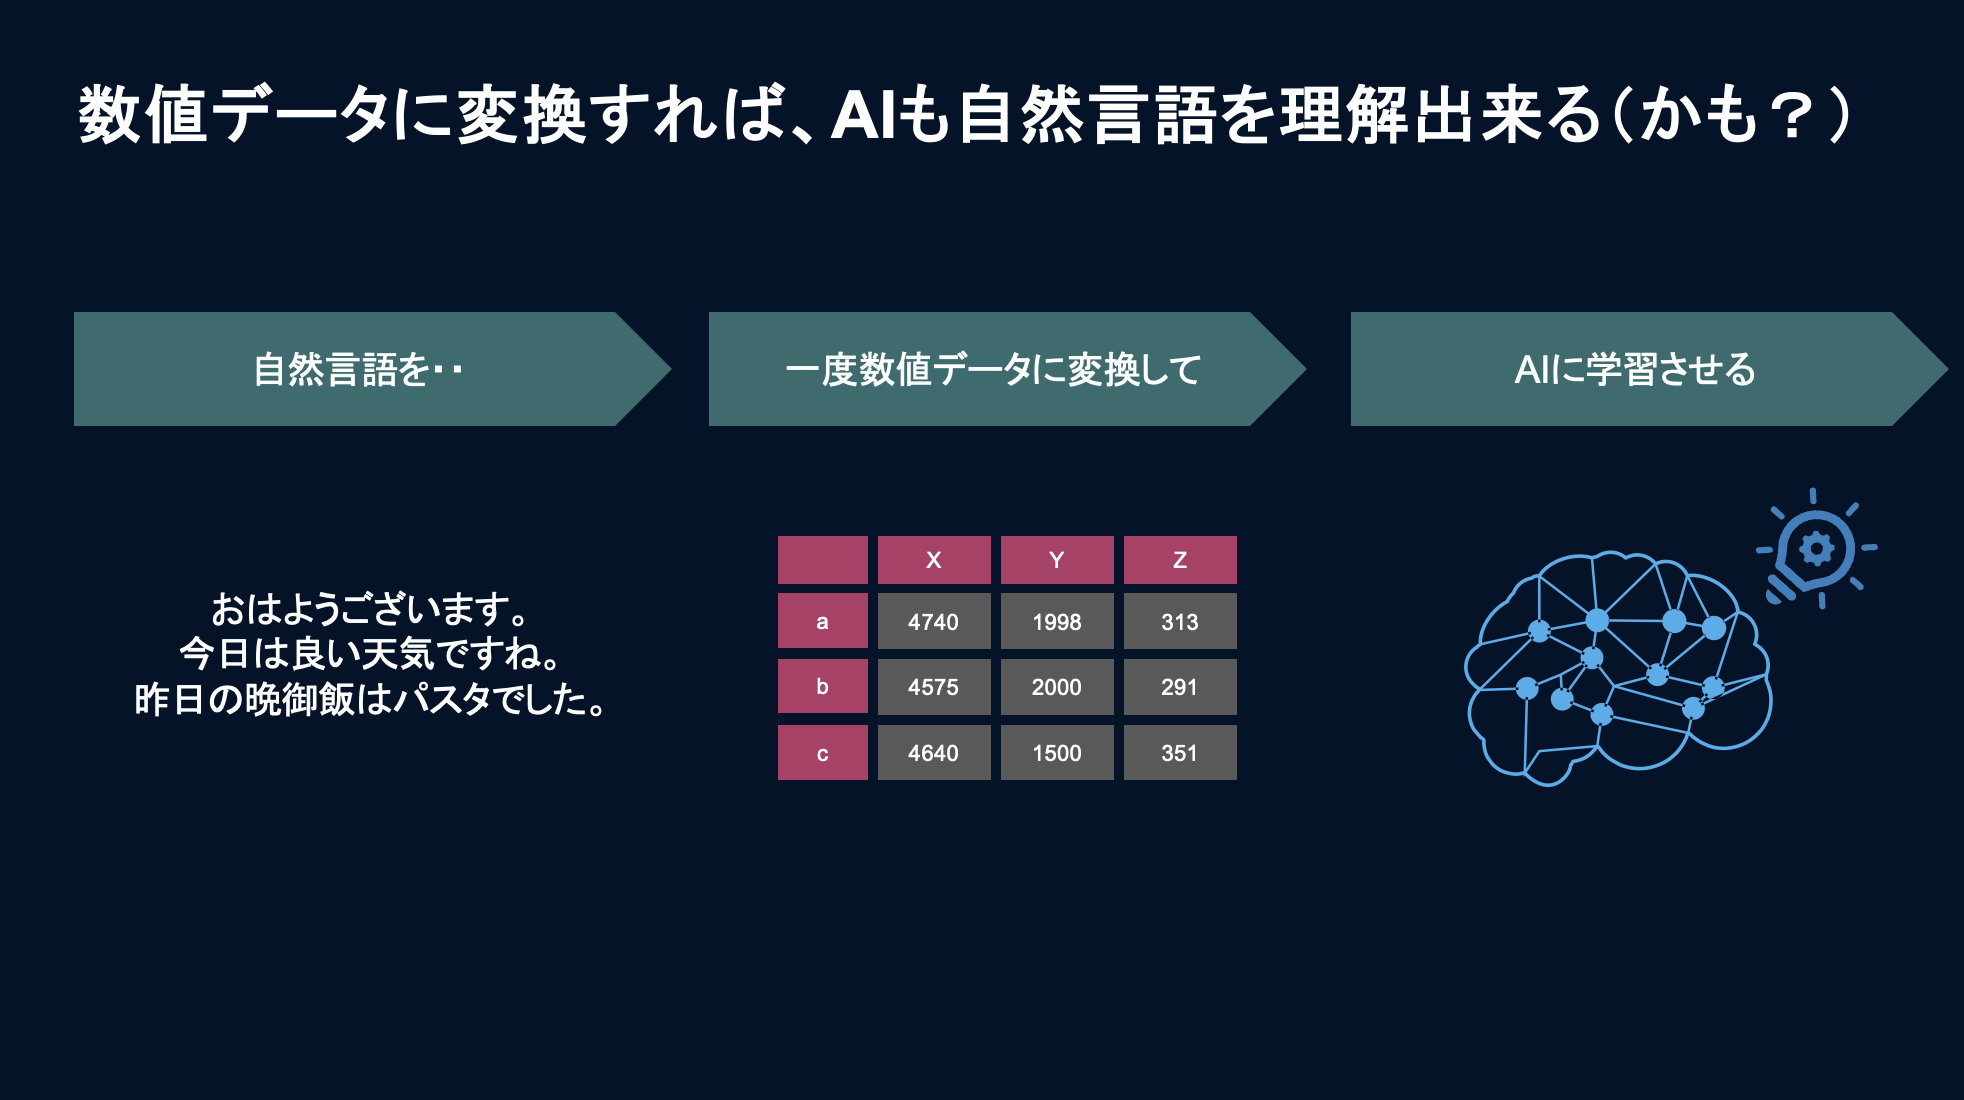

## <font color=#0e89b2>1.3 コーパスとは</font>

また、自然言語処理の分野で大切になるのが<font color=#f27405>コーパス</font>です。<br>
コーパスとは、自然言語処理を行う際に学習データとするための大量のテキストデータのことです。<br>
<br>
上で述べたようなテキスト→数値データの処理を行う際にも、学習データ（コーパス）がなければ何も手掛かりがないですもんね。<br>
<br>
例えば、以下のようなデータがコーパスとして使われます。<br>
<br>
◆公開データ
* Wikipediaのテキストデータ
* 青空文庫のテキストデータ（著作権切れの本を無料で公開しているWebサイト）

◆非公開データ
* SNSから取得したテキストデータ
* メール履歴から取得したテキストデータ
* 社内の過去の契約書から取得したテキストデータ

## <font color=#0e89b2>1.4 自然言語処理AIの活用領域</font>

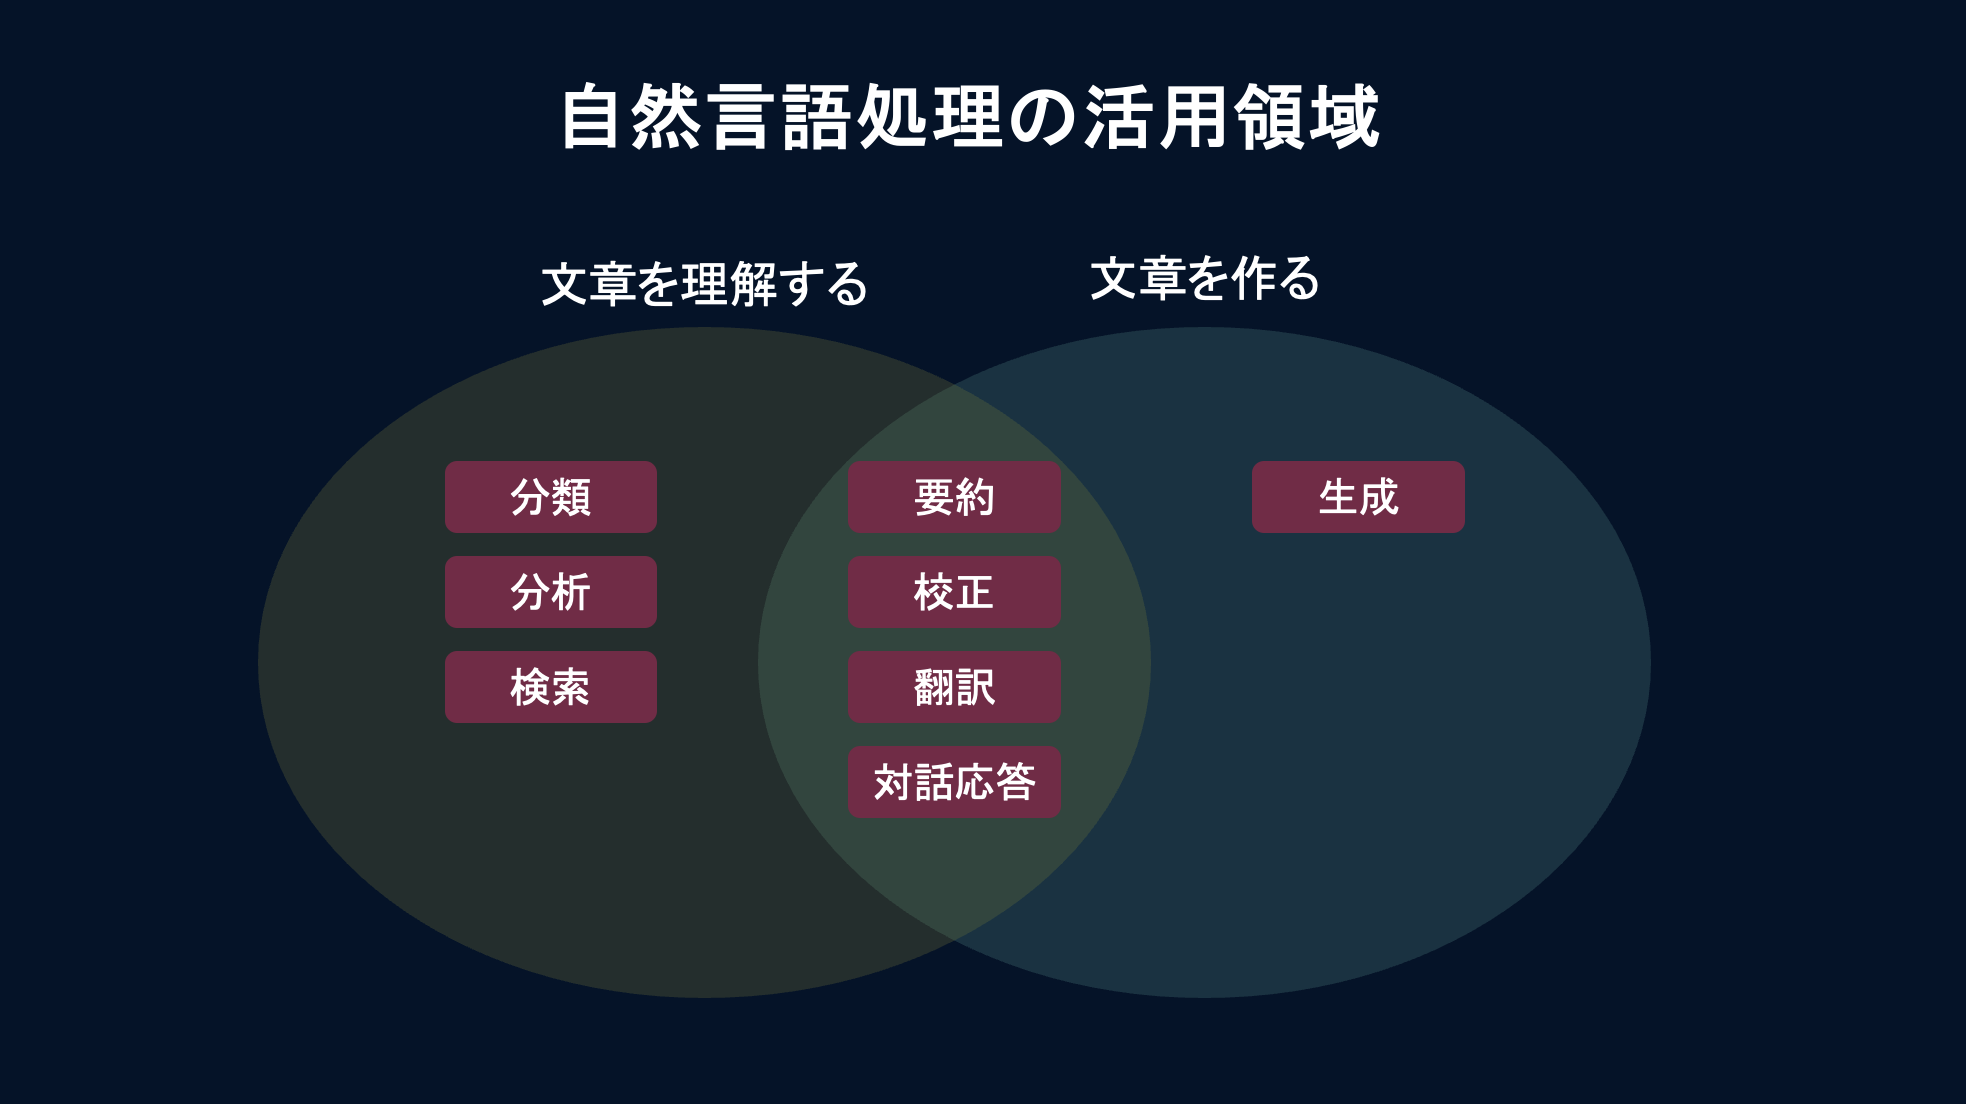

私たちが言葉を扱うとき、大まかに言うと以下の処理をしています。
* 文章を理解する
* 文章を作る（話す、書くなど）

これと対応して自然言語処理でも、以下のような対応領域があります。
* 文章を理解する→「分類」（ニュース記事のトピック分類など）、「分析」（レビューの感情分析など）
* 文章を作る→「生成」（営業資料の自動作成など）

ChatGPTのような対話応答モデルは、文章を理解した上で、適切な返事を生成しています。<br>
ですので、上記のような技術の集大成だと言えるでしょう。

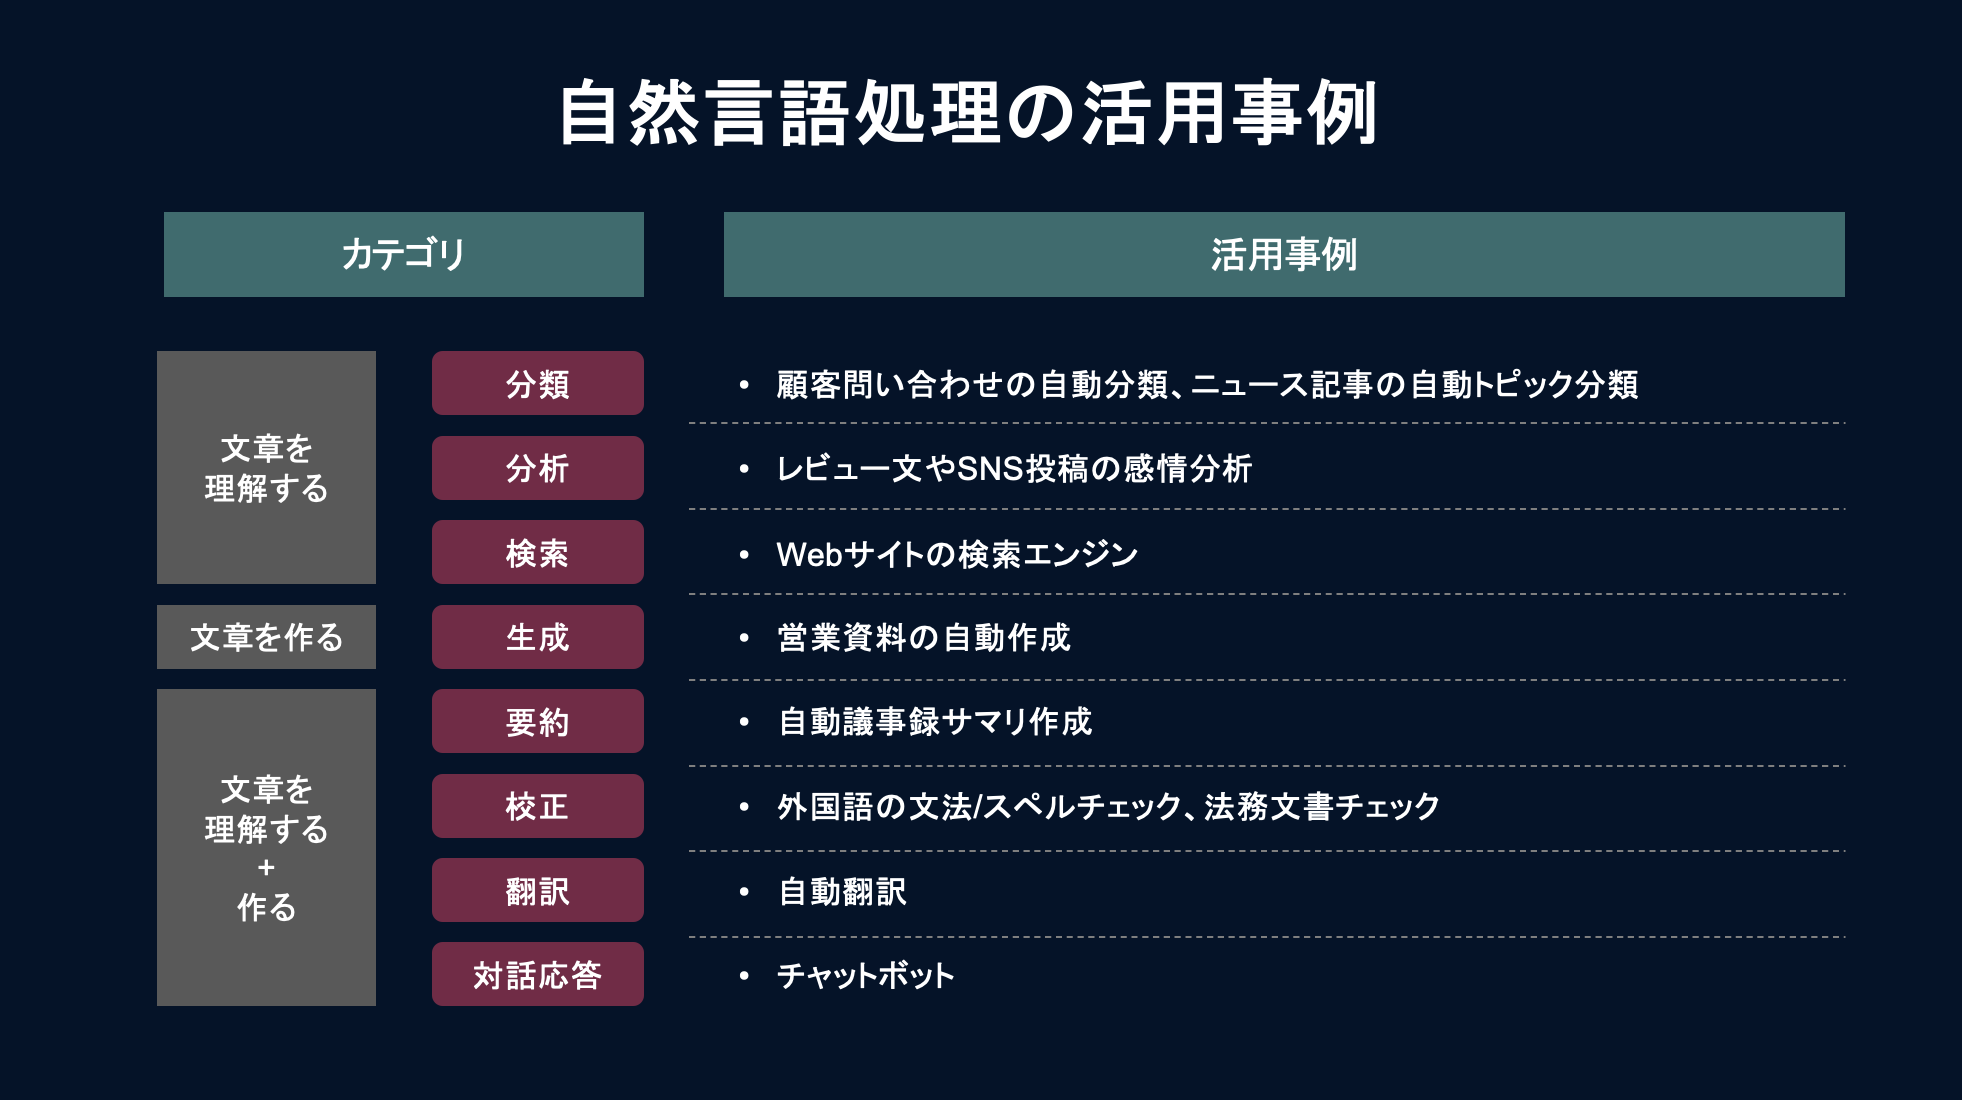

## <font color=#0e89b2>1.5 早速体験）簡単な言語判定モデルの実装</font>

### <font color=#0e89b2>a. 言語判定モデルとは？</font>

Google翻訳やDeepLのような自動翻訳サービスを利用したことがあるでしょうか？<br>
自動翻訳サービスでは、翻訳したい文章を入力すると、自動でそれが何語かを検出してくれます。<br>
この技術を「言語判定」と言います。

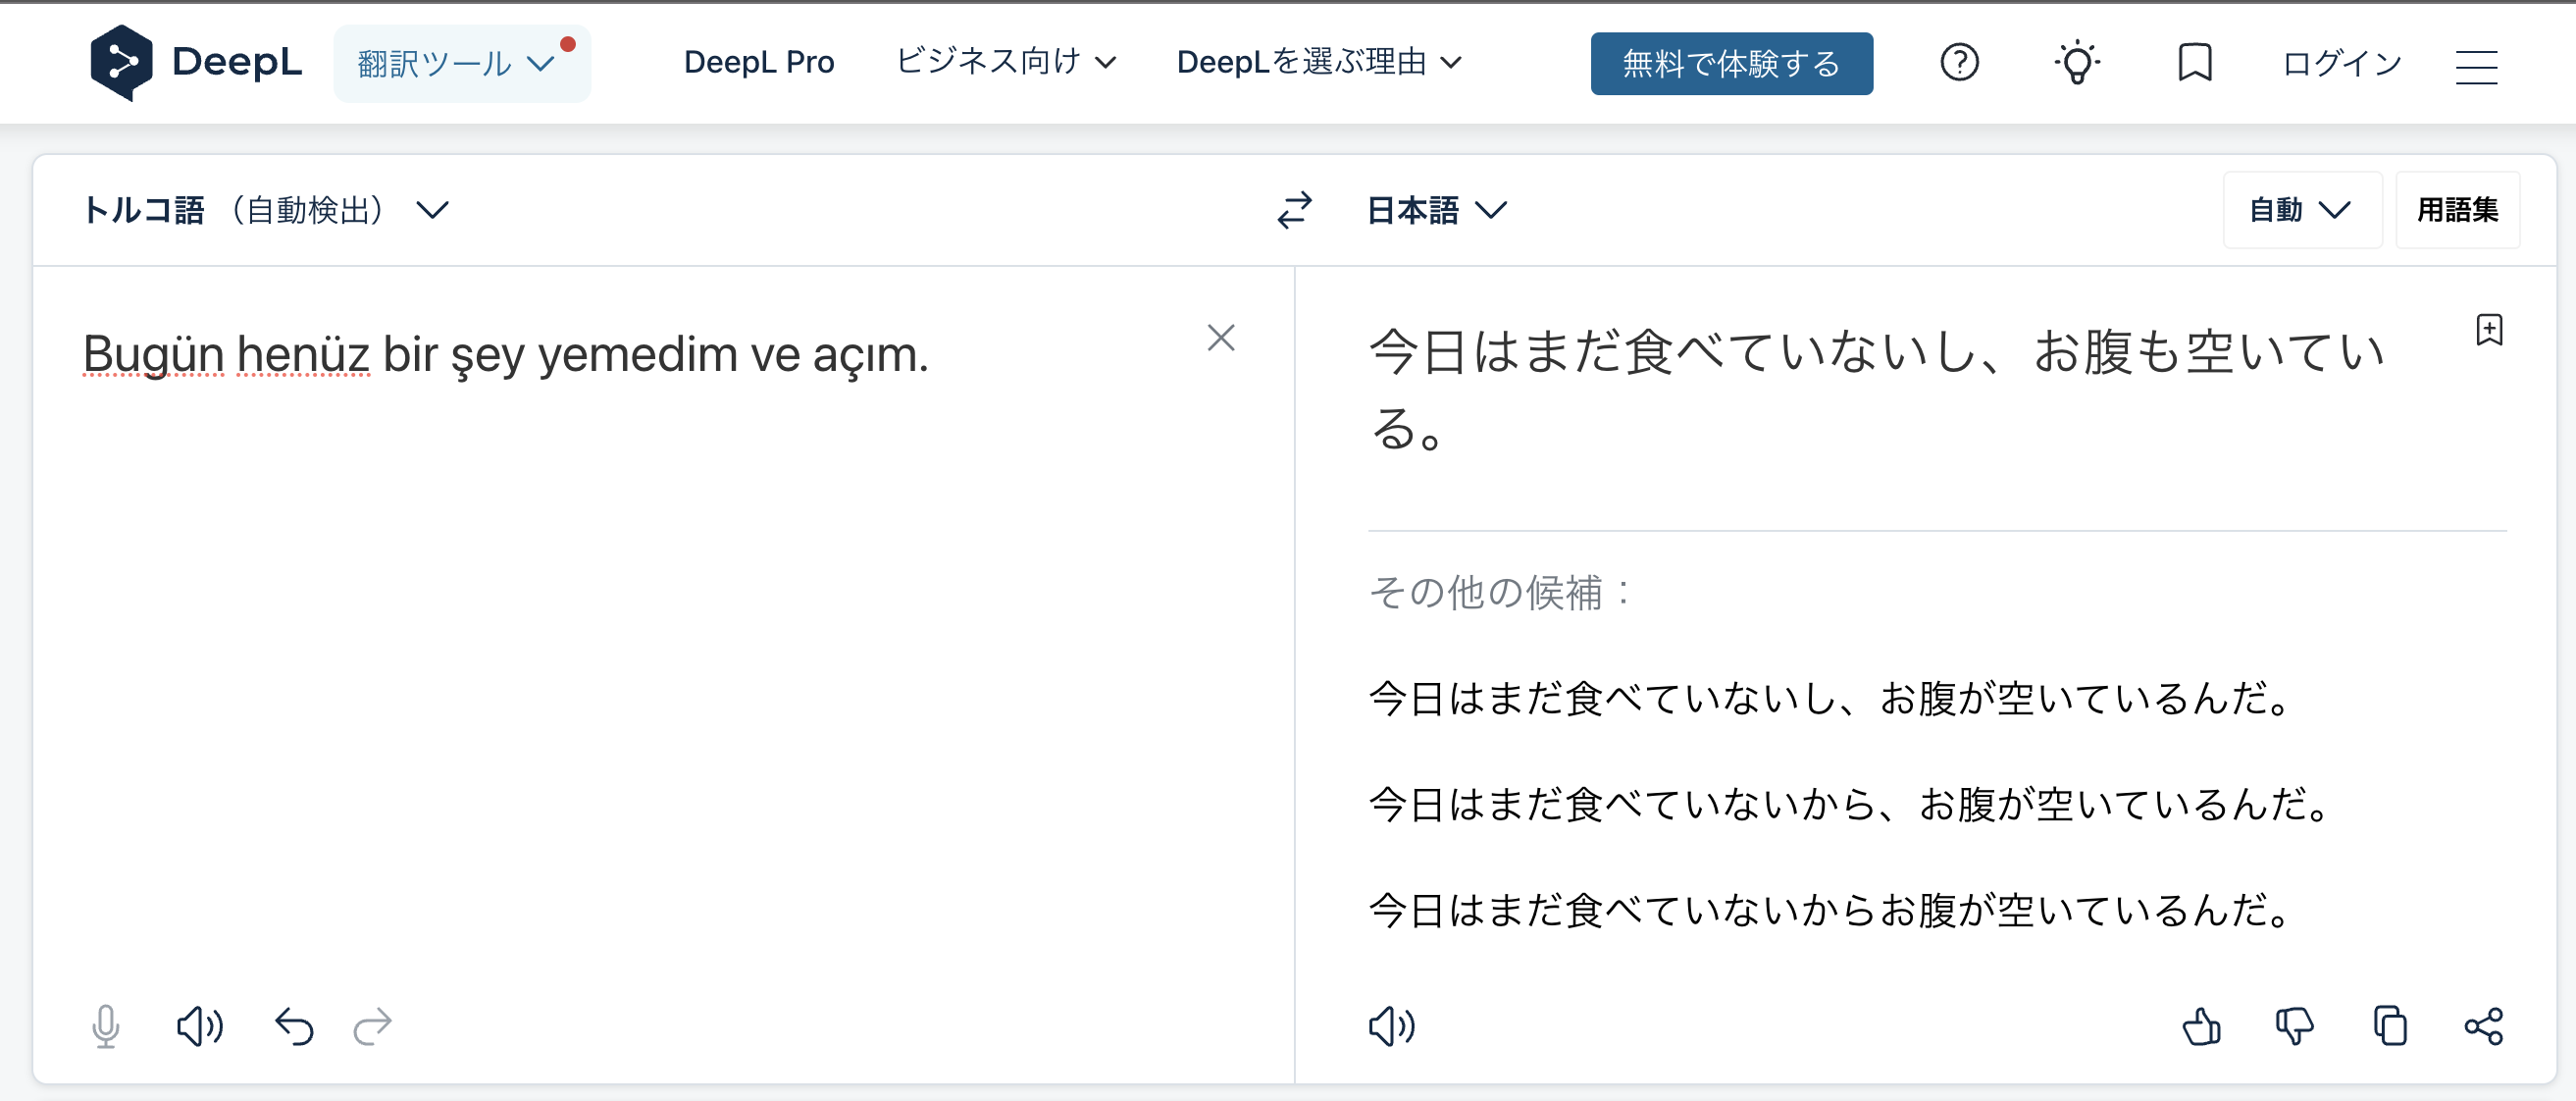

### <font color=#0e89b2>b. 言語判定モデルの大まかな仕組み</font>

では一体どのように何語か判定しているのでしょうか？<br>
<br>
◆使っている文字が異なる場合<br>
例えば日本語は平仮名や漢字が使われており、英語はアルファベットが使われているので、<br>
日本語か英語かの判定であれば簡単にできそうです。<br>
<br>
◆使っている文字が同じ場合<br>
それでは、英語とフランス語とスペイン語のように、<br>
同じ文字（アルファベット）を使っている言語を識別するためにはどうすればよいでしょうか？


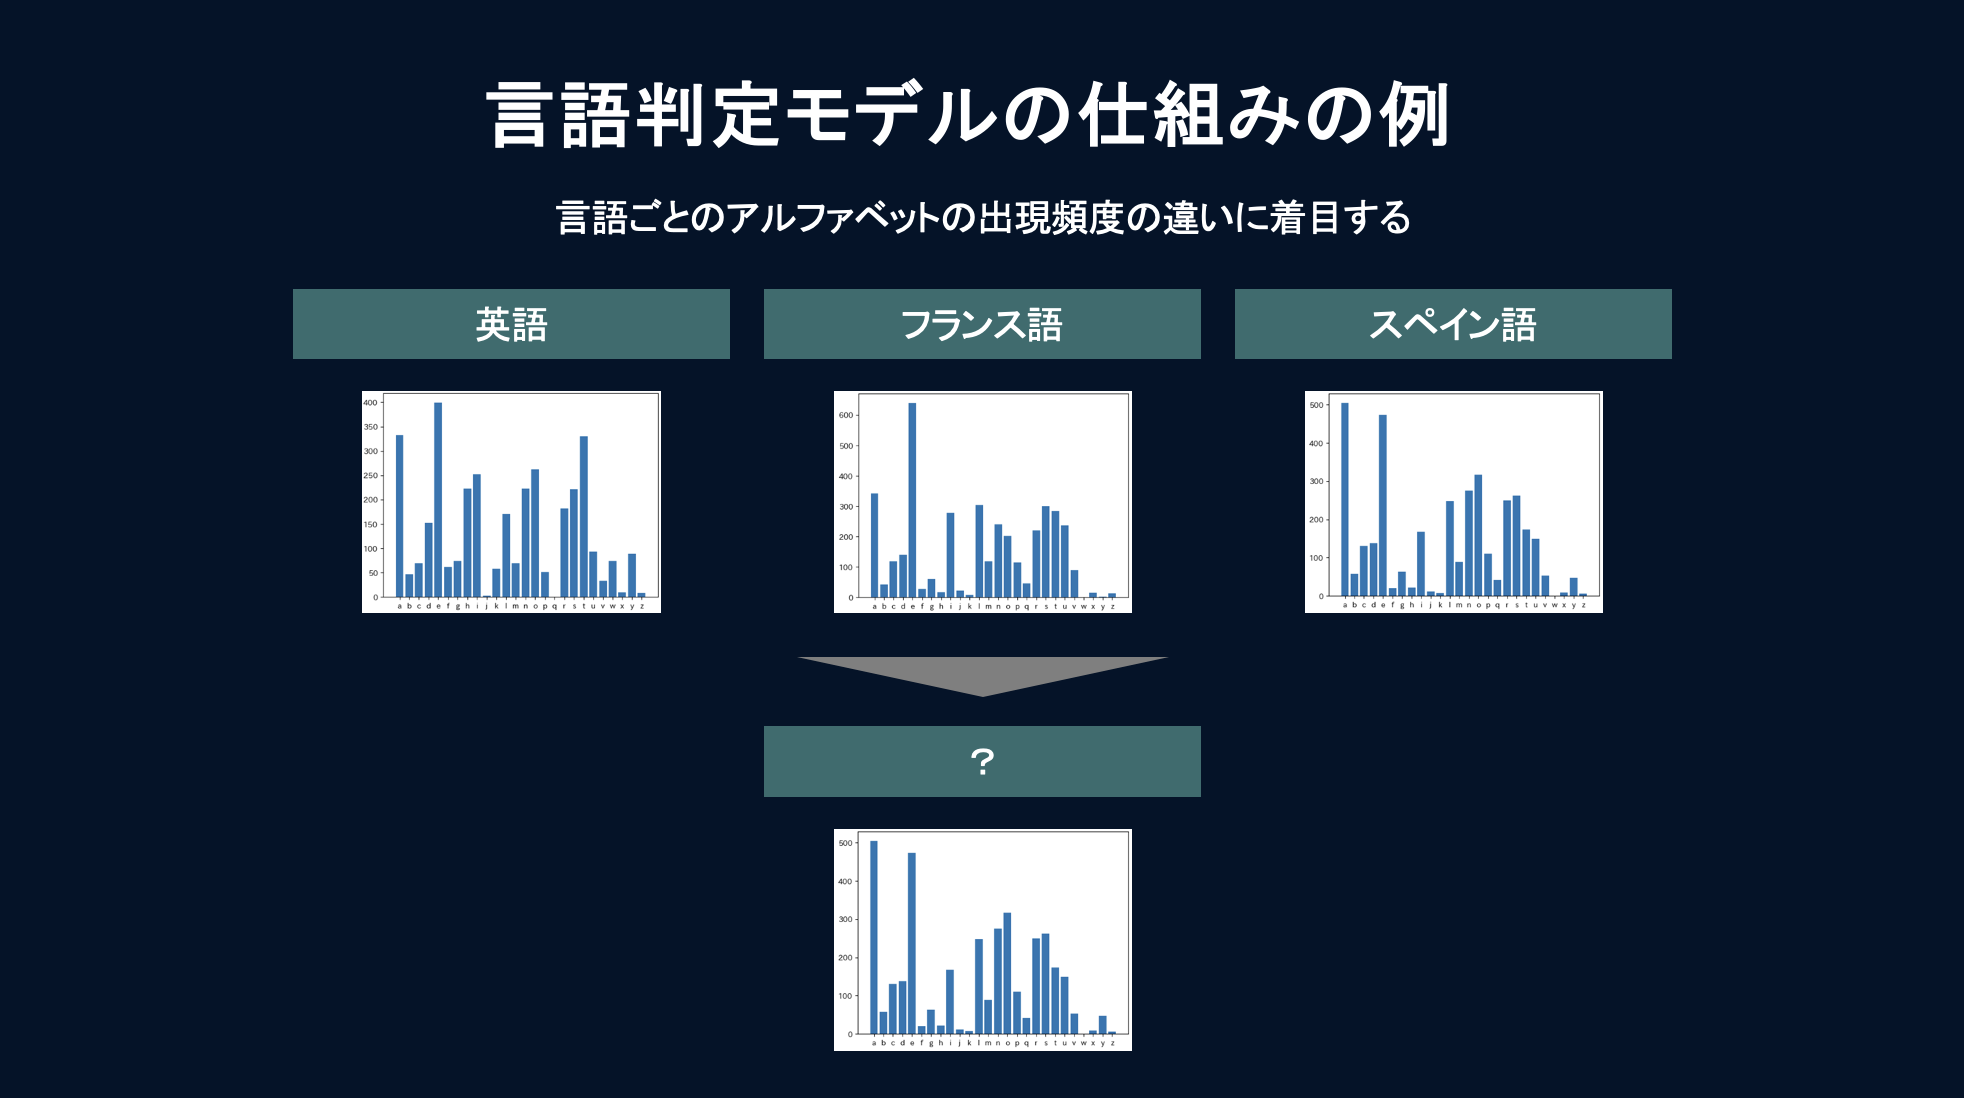

一つの方法として、「アルファベットの出現頻度の分布から推定する」というやり方があります。<br>
<br>
例えばフランス語では、UとLの出現頻度が英語よりも高いようです。<br>
（鼻母音が多く、UとLがこれらの音を発音するために使用されるため）<br>
<br>
とするとめっちゃ単純化してしまえば、UとLの出現頻度が高ければ、英語よりはフランス語である確率が高いことになります。<br>
<br>
この一つの根拠だけで判断してしまうのは心許ないですが、上のスライドのように、<br>
「分布そのものが似ているかどうか」で判断すると、より精度の高い判定が出来そうです。

### <font color=#0e89b2>c. 言語判定モデルの実装</font>

それではこの言語判定モデルを実際に実装してみましょう。<br>
実はここまで習ってきた機械学習とプログラミングのスキルがあれば作れてしまいます。

#### <font color=#0e89b2>1)学習データの準備</font>

まずは学習データとして、英語、フランス語、スペイン語の3言語のテキストデータを準備します。<br>
（ちなみにこの文章は何の文章でしょうか？）

In [ ]:
en_text = """
Then, do you all know what this vague white thing, which was said to be a river or a milk run-off, really is? He pointed to a large black constellation hanging on the blackboard, which was like a galactic belt smeared with white from top to bottom, and asked everyone what it really was.
　Cam Panella raised his hand. Then 45 people raised their hands. Giovanni was about to raise his hand, but stopped in a hurry. Giovanni had read in a magazine that they were all stars, but these days he was so sleepy in the classroom that he had neither time nor books to read, and he felt as if he didn't understand everything.
　But the teacher had already found out.
Giovanni, you know what I am talking about, don't you? You know what you're talking about, don't you?
　Giovanni stood up briskly, but when he stood up he could no longer answer clearly. Zanelli turned from his seat in front of him, looked at Giovanni and chuckled. Giovanni was so upset that he turned red. The teacher said again, "Take a look at the galaxy through the big telescope.
He looked at the galaxy through the big telescope and asked, "What do you think a galaxy is?
　Giovanni thought it was a star, but again he could not answer immediately.
　The teacher looked puzzled for a while, but then turned his eyes toward Cam panela and said, "Well then, Mr. Cam panela, what is the galaxy?
Then, "Mr. Kamperanella," he said. Then, he pointed at her name. Then, Kam panela, who had raised his hand so cheerfully, stood still and could not answer.
The teacher stared at Camperla for a while as if in surprise, then hastily said, "Well, then. Okay." He pointed to the star map himself.
If you look at this fuzzy white galaxy through a big telescope, you can already see many small stars, Giovanni, don't you agree? Don't you agree, Giovanni?
　Giovanni turned red and nodded. But then his eyes filled with tears. Yes, I knew it, and of course Camperla knew it, too, because it was in a magazine that I had read together with Camperla at her father's doctor's house. Not only that, but as soon as she read the magazine, she immediately brought out a huge book from her father's study and unfolded a section called "Ginga," and together they looked at the beautiful pictures with white dots all over the black pages for a long time. It was impossible for her to forget that, but she did not reply immediately because she felt sorry for me since I had been having a hard time at work in the morning and in the afternoon, and I did not play with everyone at school anymore and did not talk much with her anymore. I felt so sorry for myself and for her.
　The doctor said again, "Therefore, if this heavenly being is not here, then why should I be here?
So, if you consider this heavenly river to be my true river, then every little star in the river is like a grain of sand or gravel in the river. If you think of it as a huge stream of milk, it is more like the Milky Way. In other words, the stars are all like globules of fatty oil floating finely in the milk. What is like the water in the Milky Way, then, is a vacuum that transmits light at a certain speed, in which the sun and the earth also float. In other words, we are living in the waters of the Milky Way. Just as the deeper the water, the bluer it appears, so the deeper and more distant the bottom of the Milky Way, the more stars are concentrated and therefore the whiter and dimmer it appears. Look at this model.
　The teacher pointed to a large double-sided convex and convex lens with many shiny sand particles inside.
The Milky Way looks just like this. Each of these shiny particles is a star that shines by itself, just like our sun. Suppose our sun is about in the middle of the Milky Way and the earth is very close to it. You stand in the middle of this lens at night and look around. This side of the lens is so thin that you can only see a few glowing particles, i.e., stars. On the other side, the glass is thicker, so you can see a lot of glowing particles, i.e., stars, and the distant ones appear dim and white. I will tell you how big this lens is and how many stars are in it in the next science class, because it is already time to go. So, since today is the festival of the galaxy, please go outside and take a good look at the sky. That's all for now. Put away your books and notebooks.
　The classroom was filled with the sounds of opening and closing desk covers and stacking books for a while, but soon everyone stood up, bowed, and left the classroom.
"""

In [ ]:
fr_text = """
Le professeur a demandé aux élèves, en montrant une grande constellation noire accrochée au tableau, qui ressemblait à une ceinture galactique maculée de blanc de haut en bas. Le professeur montra une grande constellation noire accrochée au tableau, qui ressemblait à une ceinture galactique maculée de blanc de haut en bas, et demanda à tout le monde ce que c'était vraiment.
　Kamperla lève la main. Puis quarante-cinq autres personnes ont levé la main. Giovanni s'apprêtait à lever la main à son tour, mais il s'est arrêté précipitamment. Giovanni avait lu dans un magazine qu'ils étaient tous des stars, mais ces jours-ci, il était tellement endormi en classe qu'il n'avait pas le temps de lire ou de lire des livres.
　Mais son professeur l'avait déjà remarqué.
Giovanni, tu sais ce que je veux dire. Tu sais de quoi tu parles."
　Giovanni se leva vivement, mais en se levant, il ne pouvait plus répondre clairement. Zanelli se retourna de son siège en face de lui, regarda Giovanni et gloussa. Giovanni était tellement bouleversé qu'il devint rouge. Le professeur répète : "Regarde la galaxie dans le grand télescope.
Giovanni regarde la galaxie à travers le grand télescope et demande : "A ton avis, qu'est-ce qu'une galaxie ?"
　Giovanni pensa qu'il s'agissait d'une étoile, mais une fois de plus, il ne put répondre immédiatement.
　Le professeur reste un moment perplexe, puis tourne son regard vers Kamperla et lui dit : "Alors, M. Kamperla, qu'est-ce qu'une galaxie ?
Alors, M. Kamperla", dit-il. Puis il pointa du doigt son nom. Kam panela, qui avait levé la main si vigoureusement, se tenait toujours aussi raide et n'arrivait toujours pas à répondre.
Le professeur a regardé la cam panela pendant un moment, comme s'il était surpris, puis il s'est empressé de dire : "Alors, c'est bien. C'est bien." Il a pointé lui-même la carte des étoiles.
Quand je regarde cette galaxie blanche et floue avec un bon gros télescope, elle ressemble déjà à un tas de petites étoiles, n'est-ce pas, Giovanni ? Tu n'es pas d'accord, Giovanni ?"
　Giovanni rougit et acquiesce. Mais un jour, les yeux de Giovanni se sont remplis de larmes. Oui, je savais, bien sûr que je savais, et bien sûr que Camperla savait, que c'était dans un magazine que j'avais lu avec Camperla un jour chez le médecin de son père. Non seulement cela, mais dès qu'elle a lu le magazine, elle a sorti un énorme livre du bureau de son père et l'a ouvert à la page intitulée Ginga, et ensemble ils ont regardé les belles images avec des points blancs sur les pages noires pour toujours. Il lui était impossible d'oublier cela, mais elle n'a pas répondu tout de suite parce qu'elle était désolée pour moi, car j'avais eu beaucoup de mal à travailler le matin et l'après-midi, je ne jouais plus avec tout le monde à l'école et je ne lui parlais plus beaucoup. J'avais tellement pitié de moi et de Kam panela que je ne pouvais pas m'empêcher d'avoir pitié de moi et de Kam panela.
　Le professeur a répété.
Si vous pensez que ce fleuve du ciel et de la terre est vraiment un fleuve, alors chaque petite étoile est comme un grain de sable ou de gravier dans ce fleuve. Et si vous pensez qu'il s'agit d'un énorme ruisseau de lait, il ressemble plutôt à la Voie lactée. En d'autres termes, les étoiles sont toutes comme des boules d'huile grasse flottant finement dans le lait. Ce qui ressemble à l'eau dans la Voie lactée, c'est donc le vide, qui transmet la lumière à une certaine vitesse, et dans lequel le Soleil et la Terre flottent également. En d'autres termes, nous vivons également dans les eaux de la Voie lactée. Et lorsque nous regardons dans toutes les directions depuis les eaux de la Voie lactée, plus l'eau est profonde, plus elle apparaît bleue, tout comme plus l'eau est profonde, plus elle apparaît bleue, et plus le fond de la Voie lactée est profond et éloigné, plus il y a d'étoiles concentrées et donc plus elle apparaît blanche et faible. Regardez ce modèle".
　L'enseignant montre une grande lentille convexe et biface avec de nombreuses particules de sable brillantes à l'intérieur.
La Voie lactée ressemble à ce modèle. Chacune de ces particules brillantes est une étoile qui brille par elle-même, tout comme notre soleil. Disons que notre soleil se trouve à peu près au milieu de la Voie lactée et que la Terre en est très proche. La nuit, vous vous tenez au milieu de cette lentille et vous regardez autour de vous. Ce côté de la lentille est si fin que vous ne pouvez voir que quelques particules lumineuses, c'est-à-dire des étoiles. C'est la théorie actuelle des galaxies. Je vous expliquerai la taille de cette lentille et les différentes étoiles qu'elle contient lors du prochain cours de sciences, car il est déjà l'heure de partir. Comme c'est aujourd'hui la fête de la galaxie, vous devriez tous sortir et bien observer le ciel. C'est tout pour l'instant. Rangez vos livres et vos cahiers.
　La salle de classe fut remplie de bruits d'ouverture et de fermeture de pupitres et d'empilement de livres pendant un moment, mais bientôt tout le monde se leva, s'inclina et quitta la salle de classe.
"""

In [ ]:
es_text = """
El profesor preguntó a los alumnos, señalando una gran constelación negra colgada en la pizarra, que parecía un cinturón galáctico con una mancha blanca de arriba abajo. El profesor señaló una gran constelación negra colgada en la pizarra, que era como un cinturón galáctico embadurnado de blanco de arriba abajo, y preguntó a todos qué era en realidad.
　Kamperla levantó la mano. A continuación, otros cuarenta y cinco levantaron la mano. Giovanni estaba a punto de levantar también la mano, pero se detuvo precipitadamente. Giovanni había leído en una revista que todos eran estrellas, pero estos días tenía tanto sueño en clase que no tenía tiempo ni de leer libros.
　Pero su profesor ya se había dado cuenta.
Giovanni, ya sabes lo que quiero decir. Sabes de lo que hablas".
　Giovanni se levantó enérgicamente, pero cuando se puso en pie ya no pudo responder con claridad. Zanelli se volvió de su asiento frente a él, miró a Giovanni y soltó una risita. Giovanni estaba tan alterado que se puso rojo. El profesor volvió a decir: "Mira la galaxia a través del gran telescopio".
Giovanni miró la galaxia a través del gran telescopio y preguntó: "¿Qué crees que es una galaxia?".
　Giovanni pensó que era una estrella, pero de nuevo no pudo responder inmediatamente.
　El profesor se quedó un rato perplejo, pero luego volvió los ojos hacia Kamperla y le dijo: "Entonces, señor Kamperla, ¿qué es la galaxia?
Entonces, señor Kamperla", dijo. Luego señaló su nombre. Kam panela, que había levantado la mano con tanto ímpetu, aún se mantenía rígido y seguía sin poder responder.
El profesor se quedó mirando la cam panela un rato, como sorprendido, pero luego se apresuró a decir: "Pues bien. Bien". Y él mismo señaló el mapa estelar.
Cuando miro esta galaxia blanca y borrosa a través de un telescopio grande y bueno, ya parece un montón de estrellitas, ¿verdad, Giovanni? ¿No estás de acuerdo, Giovanni?".
　Giovanni se puso rojo y asintió. Pero un día los ojos de Giovanni se llenaron de lágrimas. Sí, lo sabía, claro que lo sabía, y claro que lo sabía Camperla, que estaba en una revista que había leído con Camperla un día en casa del médico de su padre. No sólo eso, sino que en cuanto leyó la revista, sacó un libro enorme del estudio de su padre y lo abrió por la página que se llamaba Ginga, y juntos contemplaron para siempre las hermosas fotografías con puntos blancos por todas las páginas negras. Era imposible que olvidara aquello, pero no me contestó enseguida porque le daba pena porque lo había pasado mal en el trabajo por la mañana y por la tarde, ya no jugaba con todos en el colegio y ya no hablaba mucho con ella. Sentí tanta lástima por mí y por Kam panela que no pude evitar sentir lástima por mí y por Kam panela.
　El profesor volvió a decir
Si piensas que este río del cielo y de la tierra es realmente un río, entonces cada pequeña estrella que hay en él es como un grano de arena o de grava en ese río. Y si piensas en él como una enorme corriente de leche, se parece más a la Vía Láctea. En otras palabras, las estrellas son como bolas de aceite graso flotando finamente en la leche. Lo que es como el agua de la Vía Láctea, entonces, es un vacío, que transmite la luz a cierta velocidad, y en el que también flotan el Sol y la Tierra. En otras palabras, nosotros también vivimos en las aguas de la Vía Láctea. Y cuando miramos en todas direcciones desde las aguas de la Vía Láctea, cuanto más profunda es el agua, más azul aparece, al igual que cuanto más profundo es el agua, más azul aparece, y cuanto más profundo y distante es el fondo de la Vía Láctea, más estrellas se concentran y, por tanto, más blanca y tenue aparece. Mira este modelo".
　El profesor señaló una gran lente de dos caras, convexa y abombada, con muchas partículas de arena brillante en su interior.
La Vía Láctea se parece a esto. Cada una de estas partículas brillantes es una estrella que brilla por sí misma, igual que nuestro sol. Supongamos que nuestro sol se encuentra más o menos en el centro de la Vía Láctea y que la Tierra está muy cerca de él. Por la noche te colocas en medio de esta lente y miras a tu alrededor. Este lado de la lente es tan fino que sólo se ven unas pocas partículas brillantes, es decir, estrellas. Esta es la teoría actual de las galaxias. Os contaré lo grande que es esta lente y las distintas estrellas que hay en ella en la próxima clase de ciencias, porque ya es hora de irse. Ahora, como hoy es la fiesta de la galaxia, deberíais salir todos fuera y mirar bien el cielo. Eso es todo por ahora. Guardad vuestros libros y cuadernos".
　La clase se llenó de sonidos de abrir y cerrar las tapas de los pupitres y de apilar libros durante un rato, pero pronto todos se levantaron, hicieron una reverencia y abandonaron el aula.
"""

（正解は、宮沢賢治の『銀河鉄道の夜』の翻訳です）<br>
<br>
これらのテキストのアルファベットの出現数及び出現頻度を集計して、可視化してみましょう。<br>

#### <font color=#0e89b2>2)アルファベットの出現数の集計</font>

ここでUnicodeコードポイントというものを使います。<br>
Unicodeとは、世界中のあらゆる言語の文字を収録して通し番号を割り当てたものです。<br>
(なんと、絵文字や象形文字、数学記号から古代の文字に至るまで、約50万種類に対応しているそうです）<br>
<br>
そして、ここで割り振られている番号のことをコードポイントと言います。<br>
例えばアルファベットには、このようにコードポイントが割り振られています。
* 小文字のa～z→十進数の97～123
* 大文字のA～Z→十進数の65～91

In [ ]:
#アルファベットの出現頻度を集計する関数
def count_alphabet(text):
  #空の辞書を定義
  count_dict = {}
  #for文でzipを使って、a～zは十進数の97～123をiに、A～Zは十進数の65～91をjに代入
  for i,j in zip(range(97, 97+26),range(65, 65+26)):
      # chr関数を使って、Unicodeコードポイントから文字へ変換、countメソッドで文字数をカウント
      count_dict[chr(i)] = text.count(chr(i)) + text.count(chr(j))
  #辞書をデータフレームに変換して、転置
  count_df = pd.DataFrame(count_dict.values(), index=count_dict.keys()).T
  #戻り値として、count_dfを返す
  return count_df

英語の文章のアルファベットの出現数をカウントしてみましょう。

In [ ]:
#####写経#####
count_en = count_alphabet(en_text)
count_en

,a,b,c,d,e,f,g,h,i,j,...,q,r,s,t,u,v,w,x,y,z
0,333,47,69,152,399,62,74,222,252,3,...,0,182,221,330,93,33,74,9,89,8


英語の文章のアルファベットの出現数を棒グラフで可視化してみます。

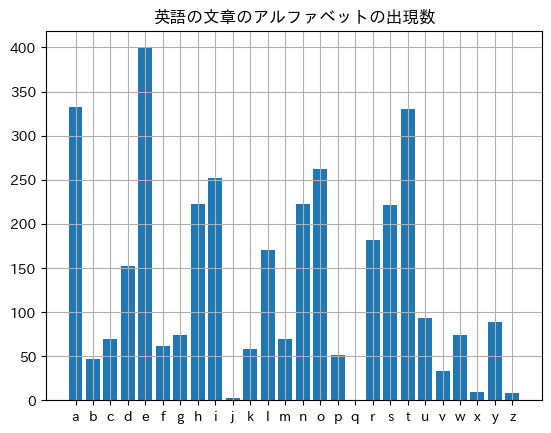

In [ ]:
#リスト内包表記で、 xに0から25の数字を入力
x = [ i for i in range(26) ]

#labels変数にa～zの項目(カラム)名を入力、グラムのラベルに使用
labels = count_en.columns.values

#matplotlibで可視化
plt.bar(x, count_en.loc[0])
plt.xticks(x, labels)
plt.title('英語の文章のアルファベットの出現数')
plt.grid(True)
plt.show()

フランス語の文章のアルファベットをカウントしてみましょう。

In [ ]:
#####写経#####
count_fr = count_alphabet(fr_text)
count_fr

,a,b,c,d,e,f,g,h,i,j,...,q,r,s,t,u,v,w,x,y,z
0,341,43,118,141,639,28,61,17,279,22,...,45,221,300,284,236,89,0,15,2,13


フランス語の文章のアルファベットの出現数を棒グラフで可視化してみます。

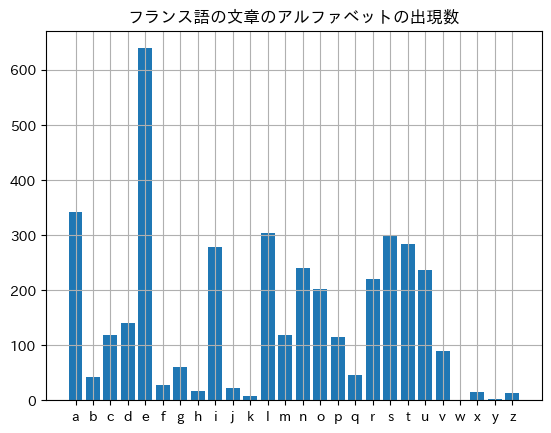

In [ ]:
#####写経#####
#matplotlibで可視化
plt.bar(x, count_fr.loc[0])
plt.xticks(x, labels)
plt.title('フランス語の文章のアルファベットの出現数')
plt.grid(True)
plt.show()

スペイン語の文章のアルファベットをカウントしてみましょう。

In [ ]:
count_es = count_alphabet(es_text)
count_es

,a,b,c,d,e,f,g,h,i,j,...,q,r,s,t,u,v,w,x,y,z
0,504,57,130,138,473,21,63,22,168,12,...,42,249,263,173,149,53,0,9,47,6


スペイン語の文章のアルファベットの出現数を棒グラフで可視化してみます。

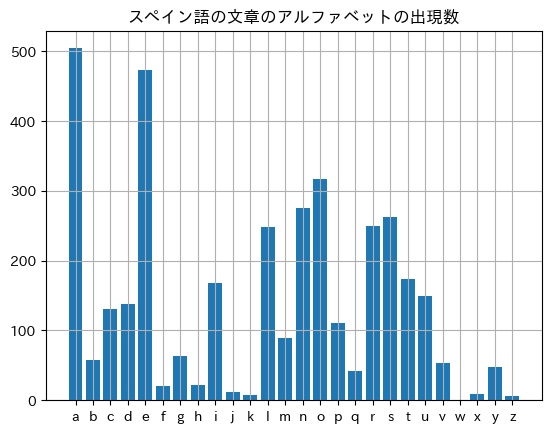

In [ ]:
#####写経#####
#matplotlibで可視化
plt.bar(x, count_es.loc[0])
plt.xticks(x, labels)
plt.title('スペイン語の文章のアルファベットの出現数')
plt.grid(True)
plt.show()

それぞれの言語ごとのアルファベットの出現頻度のデータが取れました。<br>
これが学習データになります。<br>
<br>
これに正解ラベル（英語/フランス語/スペイン語）もつけて、さらに正規化して整理しておきましょう。<br>
正規化はsklearnのpreprocessing.minmax_scaleを使用します。<br>
この処理により、各アルファベットのカウント数は最小値0、最大値1の値に変換されます。

In [ ]:
#英語の文章のアルファベットの出現数カウントを正規化
scale_count_en = preprocessing.minmax_scale(count_en.loc[0])
scale_count_en

array([0.83458647, 0.11779449, 0.17293233, 0.38095238, 1.        ,
       0.15538847, 0.18546366, 0.55639098, 0.63157895, 0.0075188 ,
       0.14536341, 0.42606516, 0.1754386 , 0.55639098, 0.6566416 ,
       0.12781955, 0.        , 0.45614035, 0.55388471, 0.82706767,
       0.23308271, 0.08270677, 0.18546366, 0.02255639, 0.22305764,
       0.02005013])

In [ ]:
#フランス語の文章のアルファベットの出現数カウントを正規化
scale_count_fr = preprocessing.minmax_scale(count_fr.loc[0])
scale_count_fr

array([0.53364632, 0.06729264, 0.18466354, 0.22065728, 1.        ,
       0.04381847, 0.09546166, 0.02660407, 0.43661972, 0.03442879,
       0.01095462, 0.47574335, 0.18622848, 0.3771518 , 0.31611894,
       0.17840376, 0.07042254, 0.3458529 , 0.46948357, 0.44444444,
       0.36932707, 0.13928013, 0.        , 0.02347418, 0.00312989,
       0.02034429])

In [ ]:
#スペイン語の文章のアルファベットの出現数カウントを正規化
scale_count_es = preprocessing.minmax_scale(count_es.loc[0])
scale_count_es

array([1.        , 0.11309524, 0.25793651, 0.27380952, 0.93849206,
       0.04166667, 0.125     , 0.04365079, 0.33333333, 0.02380952,
       0.01388889, 0.49206349, 0.1765873 , 0.54563492, 0.62896825,
       0.2202381 , 0.08333333, 0.49404762, 0.5218254 , 0.34325397,
       0.29563492, 0.10515873, 0.        , 0.01785714, 0.09325397,
       0.01190476])

In [ ]:
#各言語の正規化されたアルファベットの出現数カウントのリストをデータフレーム代入
lang_df = pd.DataFrame([scale_count_en, scale_count_fr, scale_count_es ])

#項目(カラム)名にa～zのアルファベットを付ける
lang_df.columns =  count_en.columns.values

#目的変数langを追加する 0:英語、1:フランス語、2:スペイン語
lang_number = [0,1,2]
lang_df['lang'] = lang_number

#indexに名前を付けておく　0:'英語', 1:'フランス語', 2:'スペイン語'
lang_df = lang_df.rename(index = {0:'英語', 1:'フランス語', 2:'スペイン語'})

#表示
lang_df

,a,b,c,d,e,f,g,h,i,j,...,r,s,t,u,v,w,x,y,z,lang
英語,0.834586,0.117794,0.172932,0.380952,1.000000,0.155388,0.185464,0.556391,0.631579,0.007519,...,0.456140,0.553885,0.827068,0.233083,0.082707,0.185464,0.022556,0.223058,0.020050,0
フランス語,0.533646,0.067293,0.184664,0.220657,1.000000,0.043818,0.095462,0.026604,0.436620,0.034429,...,0.345853,0.469484,0.444444,0.369327,0.139280,0.000000,0.023474,0.003130,0.020344,1
スペイン語,1.000000,0.113095,0.257937,0.273810,0.938492,0.041667,0.125000,0.043651,0.333333,0.023810,...,0.494048,0.521825,0.343254,0.295635,0.105159,0.000000,0.017857,0.093254,0.011905,2


#### <font color=#0e89b2>2)モデルの構築</font>

ここからモデルを構築していきます。<br>
どの分布の形に似ているかを判定するモデルを作りたいわけですが、これは機械学習の大得意分野でしたね。<br>
<br>
どのようなアルゴリズムがいいでしょうか。（ぶっちゃけ割と何でも良さそうですが）<br>
久しぶりにscikit-learnのアルゴリズムチートシートを参照してみます。

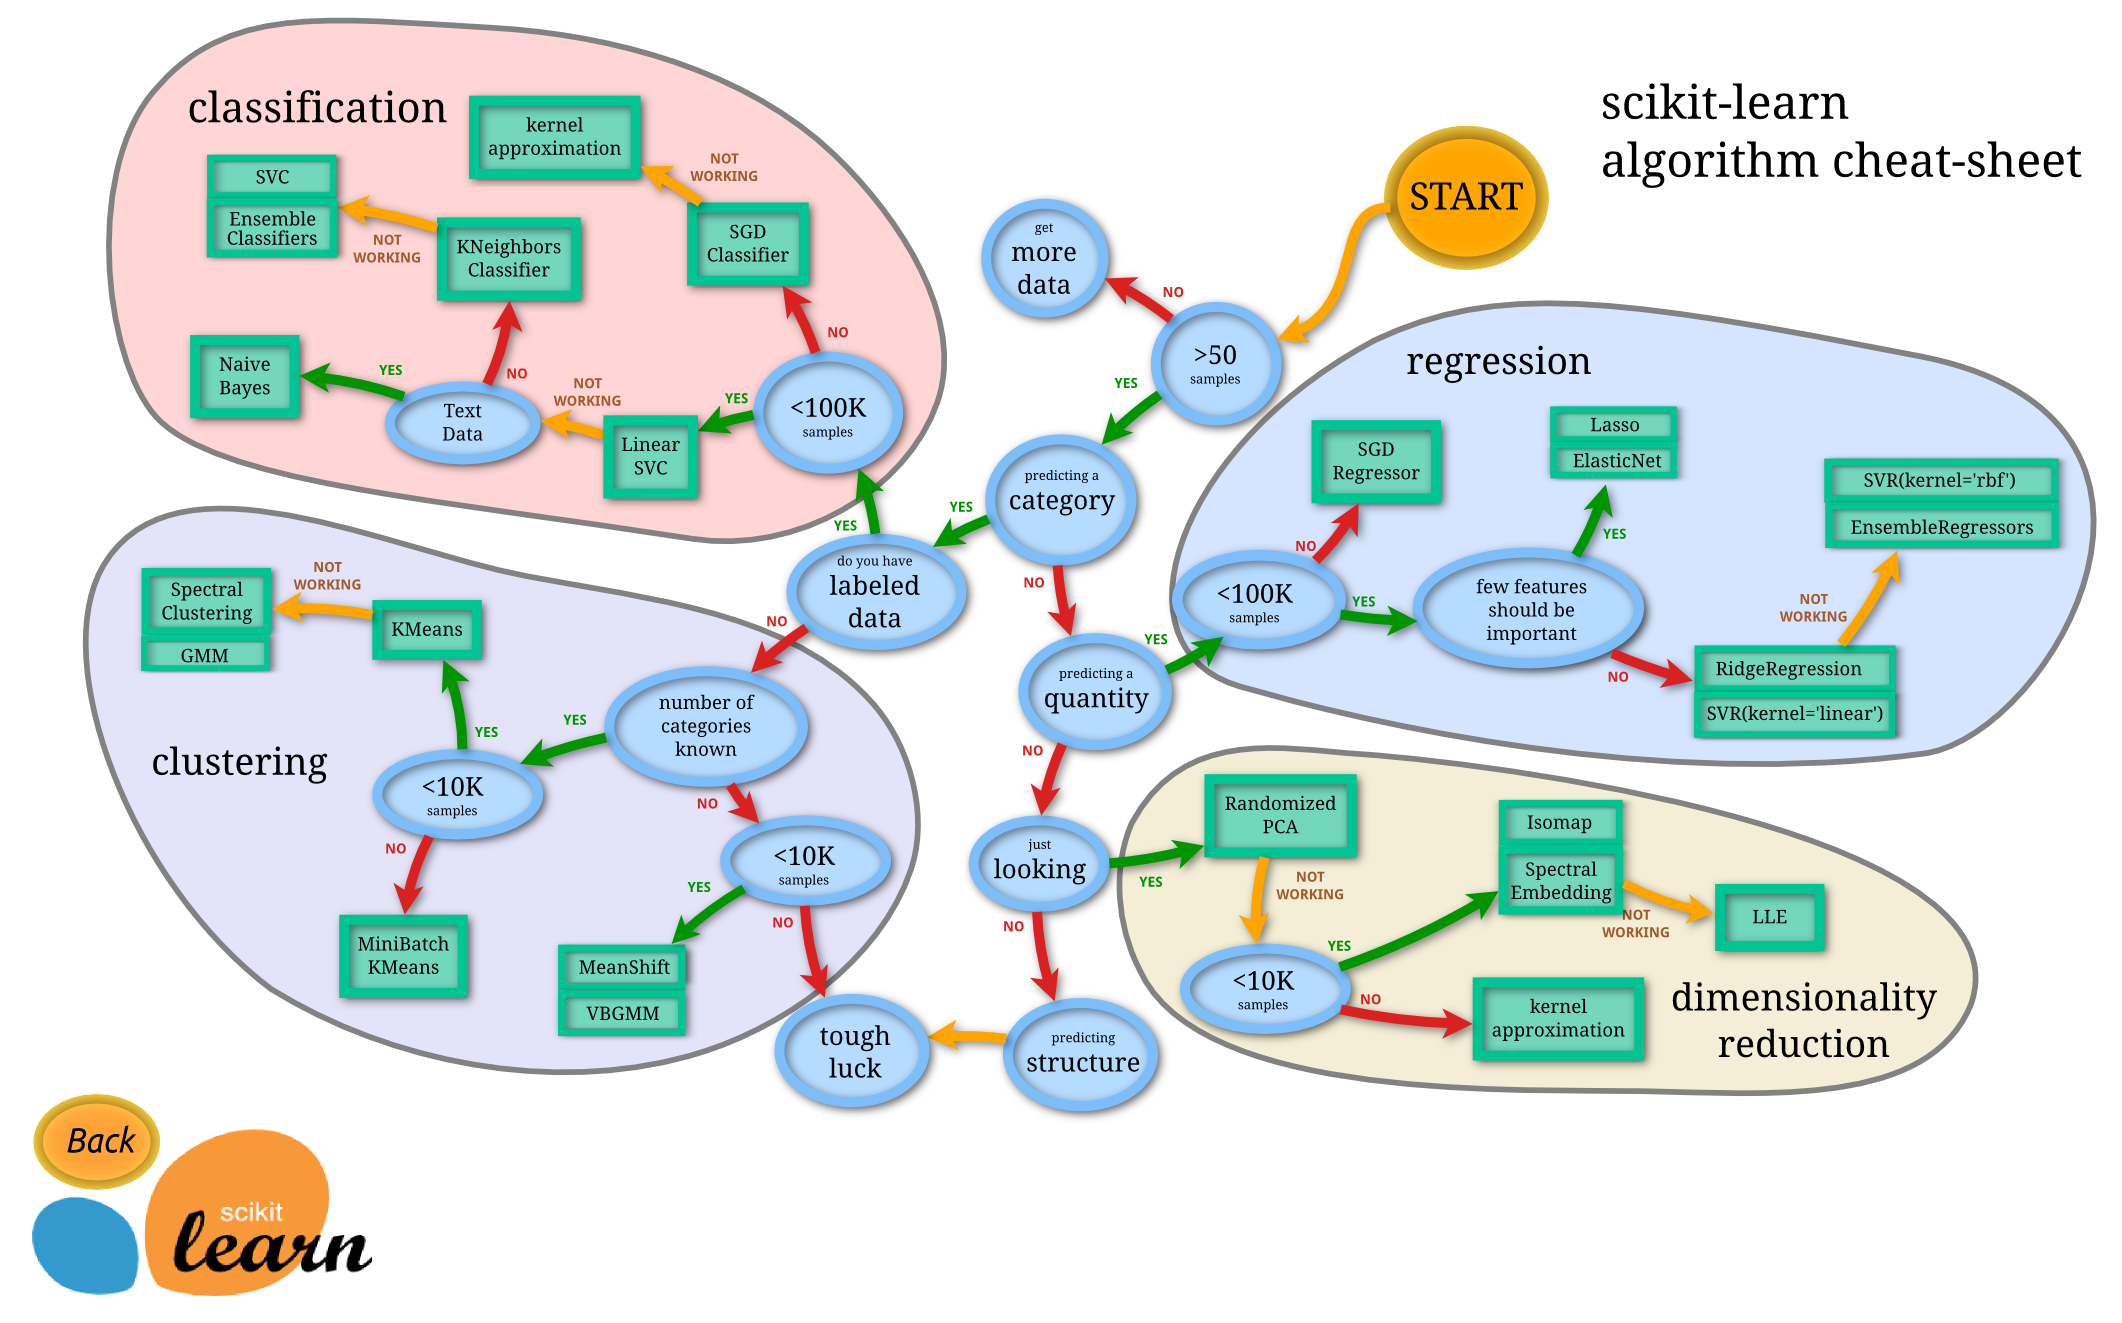

チートシートをみると、"LinearSVC"が"Not Working"の場合で、<br>
"Text Data"の場合は"Naive Bayes"が推奨されています。<br>
<br>
今回はテキストデータなので、<font color=#f27405>ナイーブベイズ</font>を使っていきましょう。<br>
<br>
ちなみに、ナイーブベイズは、<font color=#f27405>データサイズが超巨大なときに威力を発揮</font>するアルゴリズムです。<br>
<br>
今回はそれほどでもないですが、後ほど出てくるように、<br>
テキストデータを数値データ化した際にはデータサイズが超巨大になりやすいので、<br>
ナイーブベイズが推奨されています。

ナイーブベイズのモデルを構築して、学習、予測を行ってみましょう。

In [ ]:
#####写経#####
#モデルの構築
model = GaussianNB()

#説明変数を準備　lang_dfから目的変数を取り除く
x_train = lang_df.drop('lang',axis=1)

#説明変数を準備
y_train = lang_df['lang']

#### <font color=#0e89b2>3)学習・予測</font>

In [ ]:
#####写経#####
#モデル学習
model.fit(x_train, y_train)

GaussianNB()

英語の予測用テストデータを準備します。テストデータも宮沢賢治の『銀河鉄道の夜』の翻訳です。

In [ ]:
en_test ="""Behind the pasture was a loose hill, its black, flat summit dimly visible below the Ursa Major to the north, lower than usual.
　Giovanni continued up the path through the dewy woods. The small path was illuminated by a single white starlight through the dark grass and the thicket of bushes that looked like many different shapes. Among the grasses, there were small insects that emitted a shining blue light, and some of the leaves were shaded in blue.
　As he passed through the dark forest of pine trees and oak trees, the sky suddenly opened up, and he could see the river of heavenly clouds stretching from south to north, and he could also make out a pillar with a weather wheel at its peak. The flowers of the Lily of the valley and the wild chrysanthemum were blooming all over the place, as if they had been scented from within a dream.
　Giovanni came to the top of the hill, under the pillar of the weather wheel, and threw himself on the cold grass.
　The lights of the town shone through the darkness like the lights of a palace at the bottom of the sea, and the voices of children singing and whistling, and the broken cries of the people could be faintly heard. The wind was howling in the distance, the grass on the hills was rustling softly, and Giovanni's sweat-soaked shirt was cool and clammy. Giovanni looked out over a wide black field from the edge of town.
　From there he could hear the sound of a train. The windows of the small train looked reddish, and Giovanni thought of the many travelers peeling apples and laughing and doing all sorts of other things."""

In [ ]:
#####写経#####
#データ前処理
#count_alphabet関数で、各アルファベットの出現回数を求める
count_en_test = count_alphabet(en_test)

#データフレームの１行目のデータを取り出して正規化する
scale_count_en_test = preprocessing.minmax_scale(count_en_test.loc[0])

予測を行います。

In [ ]:
#####写経#####
#予測（英語文章）
#モデル入力は2次元のarrayである必要があるので、reshapeしてモデルに入力して予測
lang_result = model.predict(scale_count_en_test.reshape(1, -1))

#結果を出力
print(lang_df.index[lang_result])

Index(['英語'], dtype='object')


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


正しく英語と判定できました。<br>
<br>
次にフランス語の予測用テストデータを準備します。

In [ ]:
fr_test = """Derrière le pâturage s'élevait une colline peu accidentée, dont le sommet noir et plat était vaguement plus bas que d'habitude sous la Grande Ourse, au nord.
　Giovanni se fraya un chemin à travers les petits sentiers boisés et humides de rosée. Le petit sentier était éclairé par une seule étoile blanche à travers l'herbe sombre et les buissons, qui avaient l'air d'avoir plusieurs formes différentes. Une partie de l'herbe était couverte de petits insectes qui émettaient une lumière bleue brillante, et certaines feuilles brillaient en bleu, comme la lumière des concombres que tout le monde avait pris plus tôt.
　Alors qu'ils traversaient la sombre forêt de pins et de chênes, le ciel s'ouvrit soudain et ils purent voir la rivière Ama traverser du sud au nord, ainsi que le pilier de la roue météorologique au sommet de la montagne. Les fleurs de la pervenche et du chrysanthème sauvage s'épanouissaient tout autour, comme si elles sortaient d'un rêve, et un oiseau passait en chantant continuellement au-dessus de la colline.
　Giovanni arriva au sommet, sous le pilier de la girouette, et jeta son corps palpitant sur l'herbe froide.
　Les lumières de la ville ressemblaient, dans l'obscurité, à celles d'un palais au fond de la mer ; on entendait faiblement les chants et les sifflements des enfants, ainsi que les cris brisés. Le vent hurlait au loin, l'herbe des collines bruissait doucement et la chemise trempée de Giovanni était fraîche et moite. Giovanni regarde les champs noirs qui s'étendent loin de la ville.
　De là, il pouvait entendre le bruit d'un train. Les fenêtres du petit train étaient rouges et Giovanni pensa aux nombreux voyageurs qui épluchaient des pommes, riaient ou faisaient d'autres choses."""

In [ ]:
#####写経#####
#データ前処理
#count_alphabet関数で、各アルファベットの出現回数を求める
count_fr_test = count_alphabet(fr_test)

#データフレームの１行目のデータを取り出して正規化する
scale_count_fr_test = preprocessing.minmax_scale(count_fr_test.loc[0])

予測を行います。

In [ ]:
#####写経#####
#予測（フランス語文章）
#モデル入力は2次元のarrayである必要があるので、reshapeしてモデルに入力して予測
lang_result = model.predict(scale_count_fr_test.reshape(1, -1))

#結果を出力
print(lang_df.index[lang_result])

Index(['フランス語'], dtype='object')


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


正しくフランス語と判定できました。<br>
<br>
次にスペイン語の予測用テストデータを準備します。

In [ ]:
es_test = """Detrás del prado había una colina suelta, su cima negra y plana vagamente más baja de lo habitual bajo la Gran Osa al norte.
　Giovanni se abrió paso hacia arriba a través de los pequeños senderos boscosos cubiertos de rocío. El pequeño sendero estaba iluminado por una única luz blanca de estrellas a través de la hierba oscura y la espesura de arbustos, que parecían de muchas formas diferentes. Parte de la hierba estaba cubierta de pequeños insectos que emitían una brillante luz azul, y algunas de las hojas brillaban en azul, como la luz de los pepinos que todos habían cogido antes.
　Cuando cruzaron el oscuro bosque de pinos y robles, el cielo se abrió de repente y pudieron ver el río Ama cruzando de sur a norte, y el pilar de la rueda meteorológica en lo alto de la montaña. Las flores de la vincapervinca y del crisantemo silvestre florecían por todas partes, como si hubieran salido perfumadas de un sueño, y un pájaro pasó volando, cantando continuamente por encima de la colina.
　Giovanni llegó a la cima, bajo el pilar de la noria, y arrojó su cuerpo palpitante sobre la fría hierba.
　Las luces de la ciudad parecían en la oscuridad las luces de un palacio en el fondo del mar, y se oían débilmente los cantos y silbidos de los niños, y los gritos entrecortados. El viento aullaba a lo lejos, la hierba de las colinas crujía suavemente y la camisa empapada de sudor de Giovanni estaba fresca y húmeda. Giovanni miró hacia los negros campos abiertos, lejos de los límites de la ciudad.
　Desde allí se oía el ruido de un tren. Las ventanillas del pequeño tren parecían rojas, y Giovanni pensó en los numerosos viajeros pelando manzanas, o riendo, o haciendo otras cosas diversas."""

In [ ]:
#####写経#####
#データ前処理
#count_alphabet関数で、各アルファベットの出現回数を求める
count_es_test = count_alphabet(es_test)

#データフレームの１行目のデータを取り出して正規化する
scale_count_es_test = preprocessing.minmax_scale(count_es_test.loc[0])

予測を行います。

In [ ]:
#####写経#####
#予測（スペイン語文章）
#モデル入力は2次元のarrayである必要があるので、reshapeしてモデルに入力して予測
lang_result = model.predict(scale_count_es_test.reshape(1, -1))

#結果を出力
print(lang_df.index[lang_result])

Index(['スペイン語'], dtype='object')


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


正しく英語/フランス語/スペイン語の判定ができました。<br>
<br>
初めての自然言語処理モデルの実装、おめでとうございます！

# <font color=#0e89b2>2. 文章を品詞に分解する</font>

## <font color=#0e89b2>2.1 わかち書き</font>

テキスト処理をするためには、まず文章を単語ごとに分割する必要があります。<br>

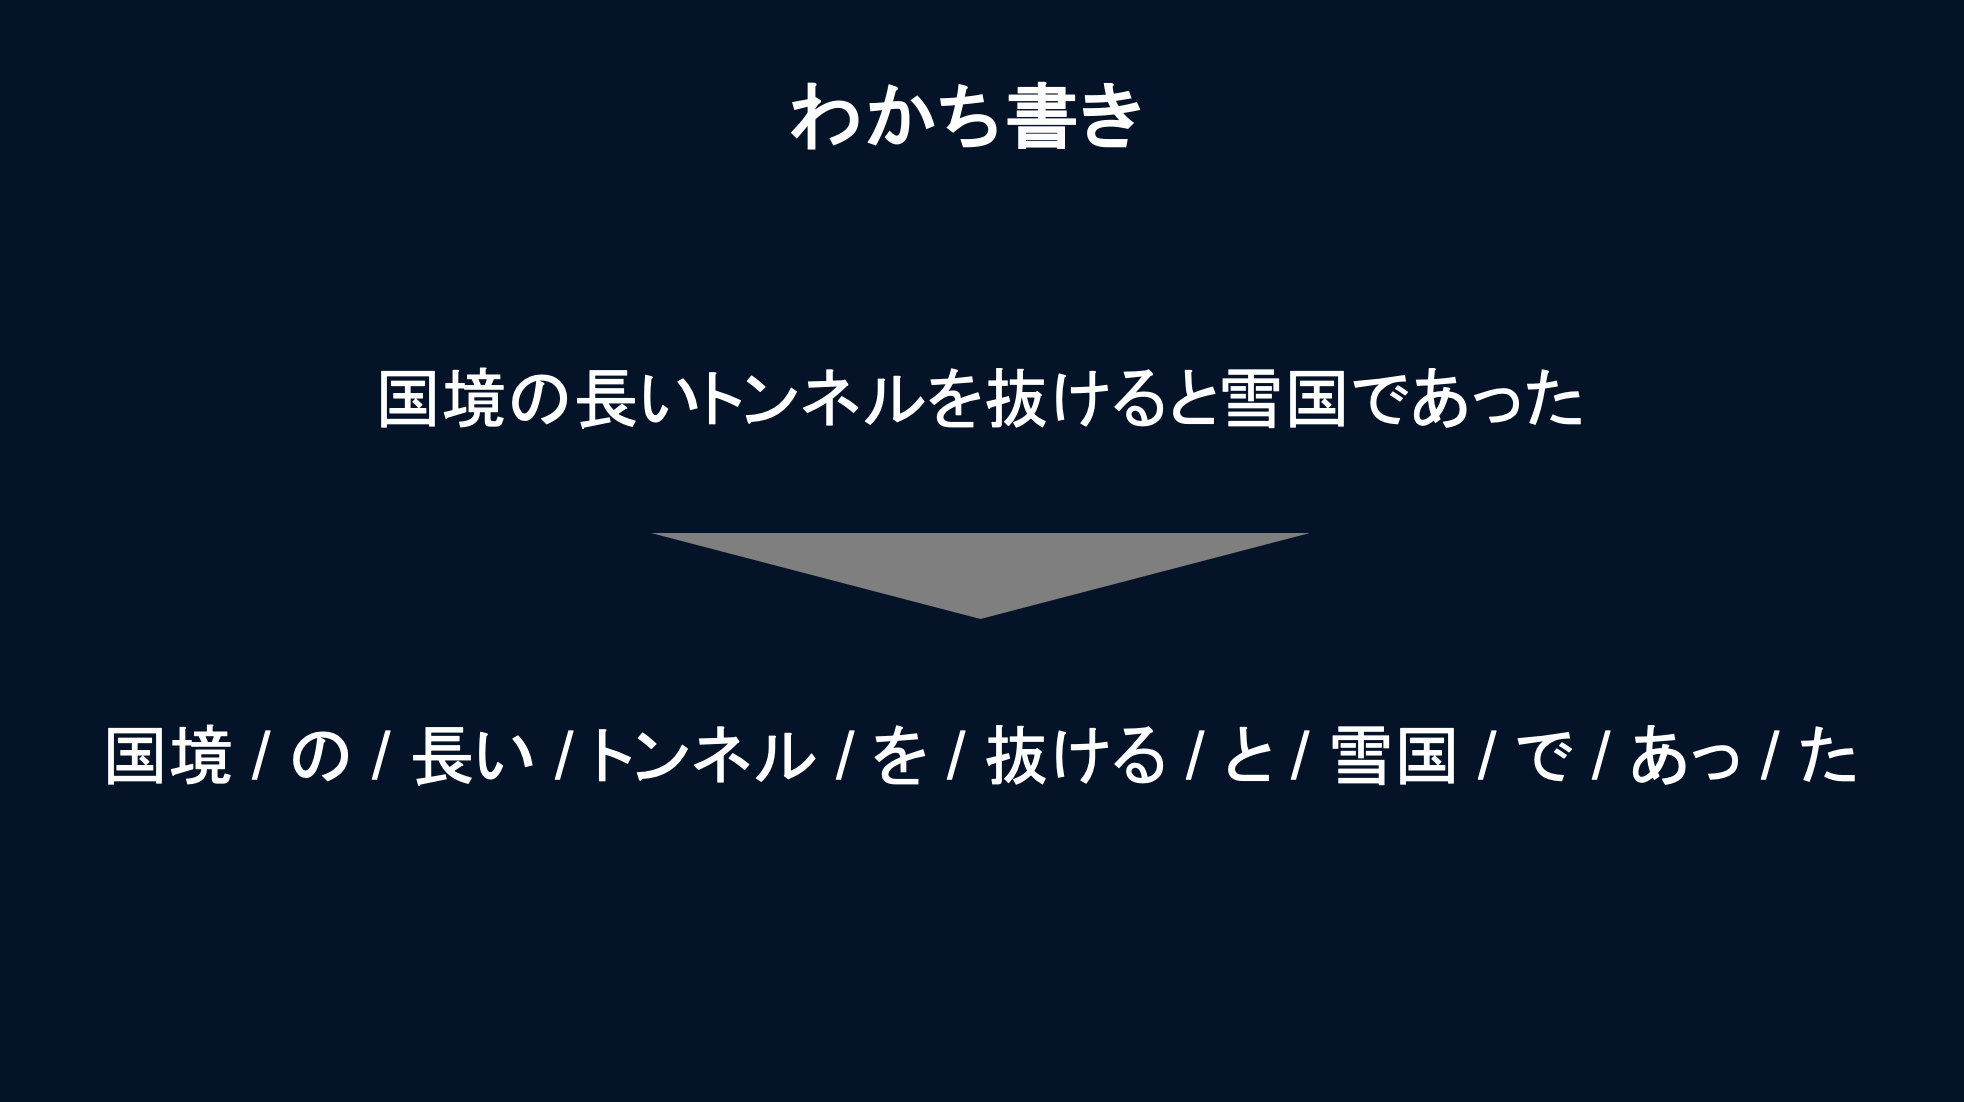

英語では単語ごとにスペースで区切られているので簡単ですが、<br>
日本語ではどのように単語を分割するのでしょうか？<br>
<br>
下の図をご覧ください。<br>
かなりかいつまんでいますが、わかち書きの仕組みについて説明します。<br>
<br>


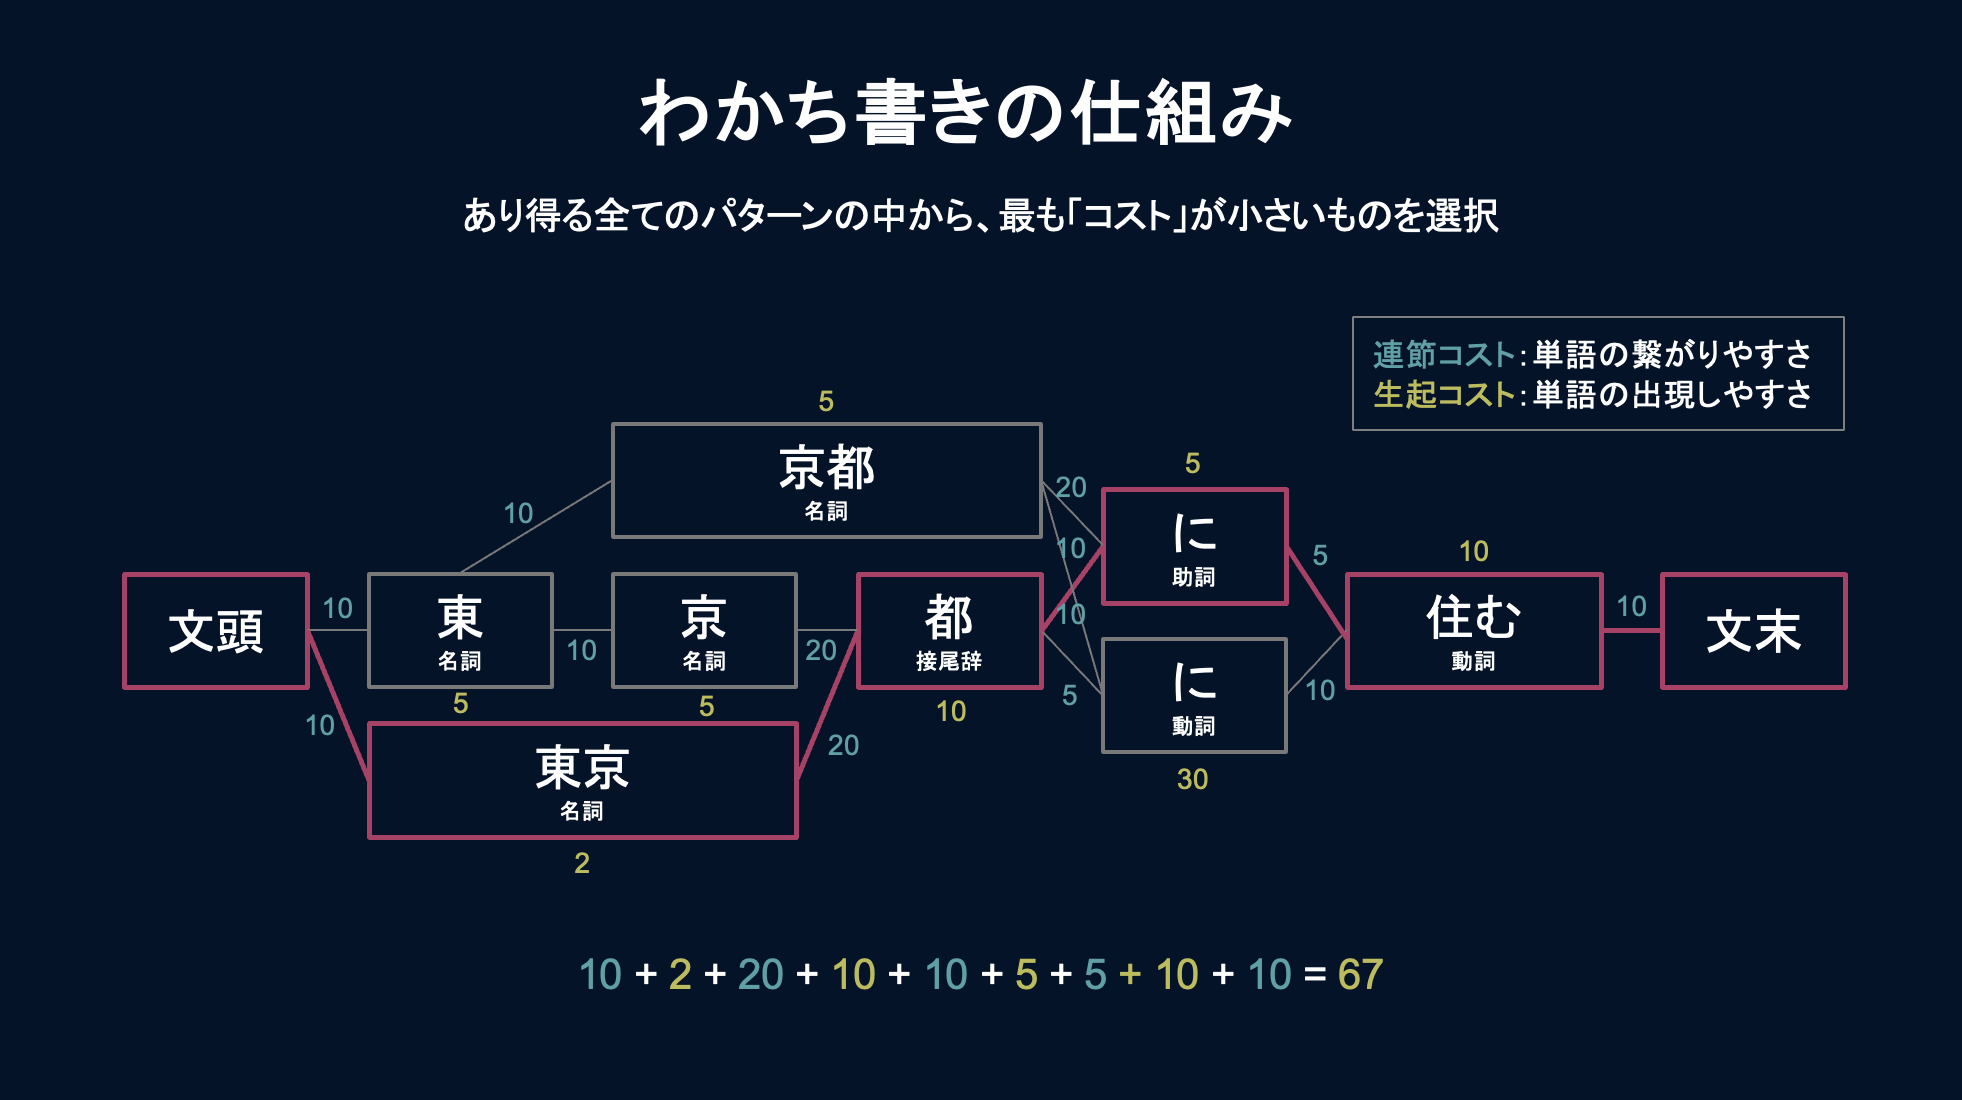

例えば、「東京都に住む」という文章をわかち書きしたいとします。<br>
まずは、<font color=#f27405>辞書データを参照しながら</font>、あり得るわかち書きのパターンを全て列挙します。<br>
次に、その中で最も繋がりが自然なものを選びます。<br>
どのようにその「自然」さを判断するかについては、「連節コスト」と「生起コスト」の和が最小になるものを選んでいます。<br>
<br>
* 連節コスト:「この単語とこの単語ってあんま繋がることなくね？」を数値化したもの
 * 例）「私」と「は」は繋がりやすいのでコストが低い
 * 例）「私」と「ます」は繋がりにくいのでコストが高い
* 生起コスト:「この単語ってそもそもあんま使われなくね？」を数値化したもの
 * 例）「言う」はよく使われる単語なのでコストが低い
 * 例）「あげつらう」はそれほど使われない単語なのでコストが高い

## <font color=#0e89b2>2.2 形態素解析</font>

### <font color=#0e89b2>a. 形態素解析とは？</font>

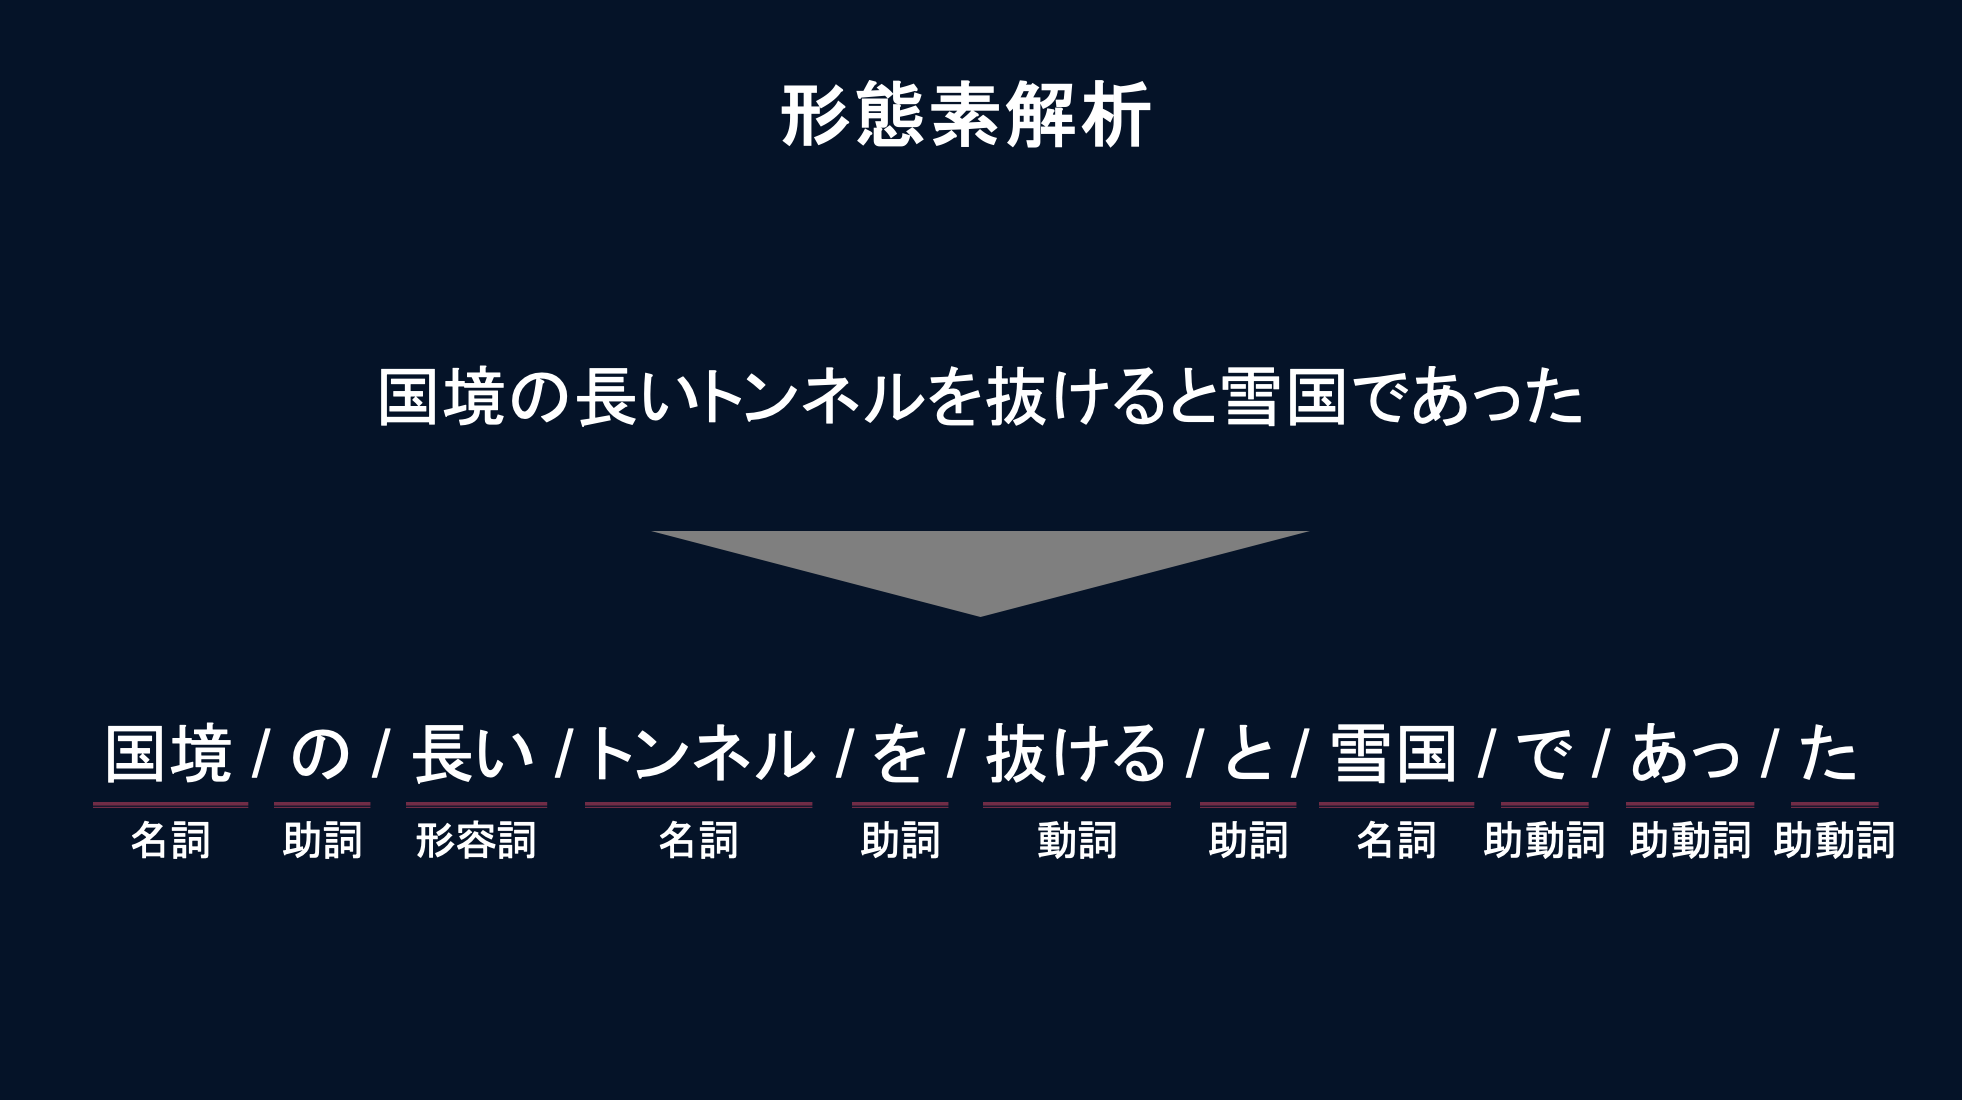

形態素解析とは、文章を言語的に意味を持つ最小単位(＝形態素)に分け、それぞれの品詞などを判別することです。<br>
仕組みは、先ほどのわかち書きの仕組みを思い返しましょう！

### <font color=#0e89b2>b. 形態素解析の実行</font>

ここではjanome(ジャノメ)というライブラリを使って、形態素解析を実行していきます。<br>
janomeはPythonで使用できる形態素解析ライブラリです。<br>
pipコマンドで簡単にインストールすることができます。（冒頭でインストール済み）

janomeのトークナイザーを生成します。<br>
トークナイザとは<br>
自然言語処理を行うためには、まず文章を単語（＝トークン）に分解するトークナイズを行い、コンピューターが処理できる入力形式に変換しなければいけません。それを実行するプログラムが「トークナイザ」です。

In [ ]:
#####写経#####
from janome.tokenizer import Tokenizer

#辞書を読み込み、解析プログラムを起動状態にする（メモリを食うので、何度も実行しないようにしましょう）
t = Tokenizer()
t

In [ ]:
#####写経#####
#形態素解析したい文章を準備
line = "国境の長いトンネルを抜けると雪国であった"

#形態素解析を実行
for token in t.tokenize(line):
    print(token)

国境	名詞,一般,*,*,*,*,国境,コッキョウ,コッキョー
の	助詞,格助詞,一般,*,*,*,の,ノ,ノ
長い	形容詞,自立,*,*,形容詞・アウオ段,基本形,長い,ナガイ,ナガイ
トンネル	名詞,一般,*,*,*,*,トンネル,トンネル,トンネル
を	助詞,格助詞,一般,*,*,*,を,ヲ,ヲ
抜ける	動詞,自立,*,*,一段,基本形,抜ける,ヌケル,ヌケル
と	助詞,接続助詞,*,*,*,*,と,ト,ト
雪国	名詞,一般,*,*,*,*,雪国,ユキグニ,ユキグニ
で	助動詞,*,*,*,特殊・ダ,連用形,だ,デ,デ
あっ	助動詞,*,*,*,五段・ラ行アル,連用タ接続,ある,アッ,アッ
た	助動詞,*,*,*,特殊・タ,基本形,た,タ,タ


ちなみに、`token.surface`と指定すれば単語のみ、`token.part_of_speech`と指定すれば品詞のみを出力できます。<br>
<br>
また、以下のように`wakati=True`とすると、わかち書きを出力することもできます。

In [ ]:
#####写経#####
line = '吾輩は猫である。名前はまだない。どこで生れたか頓と見当がつかぬ'

tokens = t.tokenize(line, wakati=True)
list(tokens)

['吾輩',
 'は',
 '猫',
 'で',
 'ある',
 '。',
 '名前',
 'は',
 'まだ',
 'ない',
 '。',
 'どこ',
 'で',
 '生れ',
 'た',
 'か',
 '頓',
 'と',
 '見当',
 'が',
 'つか',
 'ぬ']

### <font color=#0e89b2>c. ユーザー辞書を追加する</font>

以下の形態素解析の例を見てましょう。

In [ ]:
for token in t.tokenize('東京スカイツリーへのお越しは、東武スカイツリーライン「とうきょうスカイツリー駅」が便利です。'):
    print(token)

東京	名詞,固有名詞,地域,一般,*,*,東京,トウキョウ,トーキョー
スカイ	名詞,一般,*,*,*,*,スカイ,スカイ,スカイ
ツリー	名詞,一般,*,*,*,*,ツリー,ツリー,ツリー
へ	助詞,格助詞,一般,*,*,*,へ,ヘ,エ
の	助詞,連体化,*,*,*,*,の,ノ,ノ
お越し	名詞,一般,*,*,*,*,お越し,オコシ,オコシ
は	助詞,係助詞,*,*,*,*,は,ハ,ワ
、	記号,読点,*,*,*,*,、,、,、
東武	名詞,固有名詞,組織,*,*,*,東武,トウブ,トーブ
スカイツリーライン	名詞,一般,*,*,*,*,スカイツリーライン,*,*
「	記号,括弧開,*,*,*,*,「,「,「
とう	副詞,助詞類接続,*,*,*,*,とう,トウ,トウ
きょう	名詞,副詞可能,*,*,*,*,きょう,キョウ,キョー
スカイ	名詞,一般,*,*,*,*,スカイ,スカイ,スカイ
ツリー	名詞,一般,*,*,*,*,ツリー,ツリー,ツリー
駅	名詞,接尾,地域,*,*,*,駅,エキ,エキ
」	記号,括弧閉,*,*,*,*,」,」,」
が	助詞,格助詞,一般,*,*,*,が,ガ,ガ
便利	名詞,形容動詞語幹,*,*,*,*,便利,ベンリ,ベンリ
です	助動詞,*,*,*,特殊・デス,基本形,です,デス,デス
。	記号,句点,*,*,*,*,。,。,。


「東京スカイツリー」が、「東京」「スカイ」「ツリー」と分割されてしまっています。<br>
これを固有名詞として認識させるには、ユーザー辞書に「東京スカイツリー」という単語を追加する必要があります。

In [ ]:
#辞書に登録する内容をnumpy.array型の変数arr_custom_dictに入力
arr_custom_dict = np.array([['東京スカイツリー','カスタム名詞','トウキョウスカイツリー']])

#変数arr_custom_dictをCSV形式のcustom_dict.csvとして、Google Colabo内のフォルダに保存
np.savetxt('custom_dict.csv', arr_custom_dict,  fmt='%s,%s,%s')

東京スカイツリーをユーザー辞書を追加して、形態素解析を行うと<br>
固有名詞の東京スカイツリーとして分割されました。

In [ ]:
#トークナイザーにさきほど定義したcustom_dict.csvをユーザー辞書として読み込み
t = Tokenizer("/content/custom_dict.csv", udic_type="simpledic", udic_enc="utf8")

#形態素解析を実行
for token in t.tokenize('東京スカイツリーへのお越しは、東武スカイツリーライン「とうきょうスカイツリー駅」が便利です。'):
    print(token)

東京スカイツリー	カスタム名詞,*,*,*,*,*,東京スカイツリー,トウキョウスカイツリー,トウキョウスカイツリー
へ	助詞,格助詞,一般,*,*,*,へ,ヘ,エ
の	助詞,連体化,*,*,*,*,の,ノ,ノ
お越し	名詞,一般,*,*,*,*,お越し,オコシ,オコシ
は	助詞,係助詞,*,*,*,*,は,ハ,ワ
、	記号,読点,*,*,*,*,、,、,、
東武	名詞,固有名詞,組織,*,*,*,東武,トウブ,トーブ
スカイツリーライン	名詞,一般,*,*,*,*,スカイツリーライン,*,*
「	記号,括弧開,*,*,*,*,「,「,「
とう	副詞,助詞類接続,*,*,*,*,とう,トウ,トウ
きょう	名詞,副詞可能,*,*,*,*,きょう,キョウ,キョー
スカイ	名詞,一般,*,*,*,*,スカイ,スカイ,スカイ
ツリー	名詞,一般,*,*,*,*,ツリー,ツリー,ツリー
駅	名詞,接尾,地域,*,*,*,駅,エキ,エキ
」	記号,括弧閉,*,*,*,*,」,」,」
が	助詞,格助詞,一般,*,*,*,が,ガ,ガ
便利	名詞,形容動詞語幹,*,*,*,*,便利,ベンリ,ベンリ
です	助動詞,*,*,*,特殊・デス,基本形,です,デス,デス
。	記号,句点,*,*,*,*,。,。,。


## <font color=#0e89b2>2.3 練習問題1：形態素解析</font>

以下の文書を形態素解析してください。<br>
"私はアメリカから来ました。名前はルーシーです。寿司が食べたいです"

解答

In [ ]:
from janome.tokenizer import Tokenizer

t = Tokenizer()

In [ ]:
line = "私はアメリカから来ました。名前はルーシーです。寿司が食べたいです"

for token in t.tokenize(line):
    print(token)

私	名詞,代名詞,一般,*,*,*,私,ワタシ,ワタシ
は	助詞,係助詞,*,*,*,*,は,ハ,ワ
アメリカ	名詞,固有名詞,地域,国,*,*,アメリカ,アメリカ,アメリカ
から	助詞,格助詞,一般,*,*,*,から,カラ,カラ
来	動詞,自立,*,*,カ変・来ル,連用形,来る,キ,キ
まし	助動詞,*,*,*,特殊・マス,連用形,ます,マシ,マシ
た	助動詞,*,*,*,特殊・タ,基本形,た,タ,タ
。	記号,句点,*,*,*,*,。,。,。
名前	名詞,一般,*,*,*,*,名前,ナマエ,ナマエ
は	助詞,係助詞,*,*,*,*,は,ハ,ワ
ルーシー	名詞,固有名詞,人名,名,*,*,ルーシー,ルーシー,ルーシー
です	助動詞,*,*,*,特殊・デス,基本形,です,デス,デス
。	記号,句点,*,*,*,*,。,。,。
寿司	名詞,一般,*,*,*,*,寿司,スシ,スシ
が	助詞,格助詞,一般,*,*,*,が,ガ,ガ
食べ	動詞,自立,*,*,一段,連用形,食べる,タベ,タベ
たい	助動詞,*,*,*,特殊・タイ,基本形,たい,タイ,タイ
です	助動詞,*,*,*,特殊・デス,基本形,です,デス,デス


# <font color=#0e89b2>3. 文章に含まれる単語をカウントする</font>

## <font color=#0e89b2>3.1 単語の出現数のカウント</font>

文章に含まれる単語の出現数をカウントすれば、文章を数値データに変換することができます。<br>
そこで、以下のテキストに含まれる単語の出現数をカウントして、データフレーム化してみましょう。

In [ ]:
text = "2023年は、歴史に深く刻まれる激動と希望が交錯した年でした。世界を震撼させたロシアによるウクライナ侵攻は長期化し、多くの犠牲者を生み出し、国際社会に深い傷跡を残しました。欧米諸国による経済制裁も、戦争終結には至らず、世界経済に暗い影を落としました。一方、東アジアでは中国が台湾への圧力を強め、台湾海峡の緊張が高まりました。中国は台湾を自国の領土の一部と主張しており、武力統一も辞さない姿勢を見せています。アメリカのバイデン政権は台湾への武器供与を強化し、中国を牽制していますが、台湾問題は米中間の緊張を高め、新たな冷戦構造を生み出す可能性があります。アメリカでは11月、中間選挙が行われ、共和党が下院で多数派を奪還しました。バイデン政権の政策運営は難航が予想され、アメリカ政治の混迷が深まる可能性があります。世界経済は、インフレ加速の影響を受け、低迷状態が続いています。エネルギー価格や食料価格の高騰は家計を直撃し、人々の生活を圧迫しています。しかし、暗闇の中に希望の光も見えました。新型コロナウイルス感染症は、オミクロン株の出現により感染者数が増加しましたが、重症化率や死亡率は低下しました。各国はワクチン接種や治療薬の開発を進め、ウィズコロナ時代の社会を模索し始めました。気候変動による異常気象は、世界各地で洪水や干ばつなどの被害をもたらしました。しかし、この危機は、人類が地球環境問題に真剣に取り組むきっかけとなりました。世界各国は、再生可能エネルギーへの投資拡大や温室効果ガスの排出削減目標の強化など、具体的な対策を講日本国内では、岸田内閣の支持率低迷や物価高騰が国民生活を苦しめました。参議院選挙では与党が改選過半数を維持しましたが、国民の不満は依然として高止まりしています。宇宙開発では、日本の探査機「はやぶさ2」が地球に帰還し、小惑星リュウグウの貴重なサンプルを持ち帰りました。また、小惑星探査機「だいち3号」も打ち上げられ、宇宙探査の新たな時代が始まりました。人工知能は、医療、教育、製造業など様々な分野で活用され、技術革新が加速しました。AIは人類の生活を豊かにする可能性を秘めていますが、倫理的な問題や安全性への懸念も指摘されています。"

In [ ]:
#####写経#####
#形態素解析を実行
tokens = t.tokenize(text)

#名詞のみを抽出した単語リストを作成
words = []
for line in tokens:
    tkn = re.split('\t|,', str(line))
    #名詞のみを抽出
    if tkn[1] in ['名詞'] :
        words.append(tkn[0])
words[:5]

['2023', '年', '歴史', '激動', '希望']

In [ ]:
#####写経#####
#単語の数を集計してデータフレームに変換
df_word_counts = pd.Series(words).value_counts().to_frame('Count')

#出現回数上位20単語に絞り込む
df_word_counts_top20 = df_word_counts[:20]

#表示
df_word_counts_top20.head()

,Count
台湾,5
世界,5
可能,4
性,4
問題,3


棒グラフで可視化もしてみます。

<Axes: >

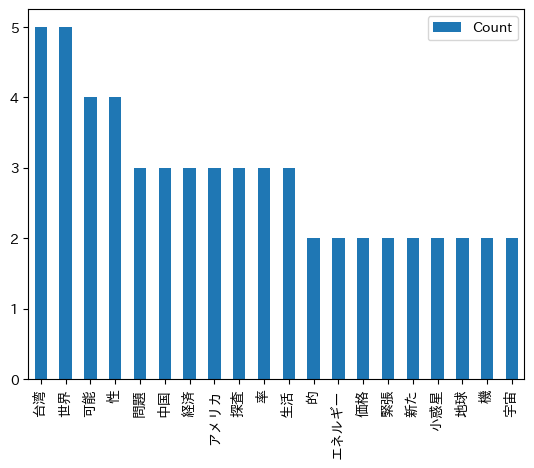

In [ ]:
#####写経#####
df_word_counts_top20.plot(kind='bar')

## <font color=#0e89b2>3.2 ストップワードの除去</font>

### <font color=#0e89b2>a. ストップワードとは？</font>

上のグラフを見ると、「性」「的」などの、あまり意味をなさない単語が含まれています。<br>
このような単語のことを、ストップワードといいます。<br>
* 日本語のストップワードの例：こちら、もの、こと etc.
* 英語のストップワードの例：can, have, it etc.

自然言語処理の分野では、このようなストップワードを除去する処理がよく行われます。<br>
ここでもストップワードの除去を行ってみましょう。<br>

### <font color=#0e89b2>b. ストップワードの除去のやり方</font>

ストップワードの除去をする場合は、既存の「ストップワードリスト」と照らし合わせながら除去するのが効率的です。<br>
<br>
こちらのファイルが、ストップワードのリストです。<br>
このファイルを読み込みます。<br>
https://drive.google.com/file/d/1D7JYvnEK-T7QeCB_tbiZa7zfTBKV8M01/view?usp=drive_link

In [ ]:
#####写経#####
stopwords = pd.read_csv("/content/ストップワード.csv")
stopwords = stopwords["ストップワード"]
stopwords

0      あそこ
1      あたり
2      あちら
3      あっち
4       あと
      ... 
305    向こう
306     何人
307     手段
308     同じ
309     感じ
Name: ストップワード, Length: 310, dtype: object

このストップワードリストと、先ほどの`df_word_counts`を照らし合わせて、<br>
ストップワードを`drop`(削除）していきます。

In [ ]:
#####写経#####
# ストップワードを除外
df_filtered = df_word_counts.drop(index=stopwords, errors='ignore')
df_filtered.head()

,Count
台湾,5
世界,5
可能,4
問題,3
中国,3


ストップワードの除去が完了しました。<br>
再び出現回数上位20単語に絞って可視化してみます。

<Axes: >

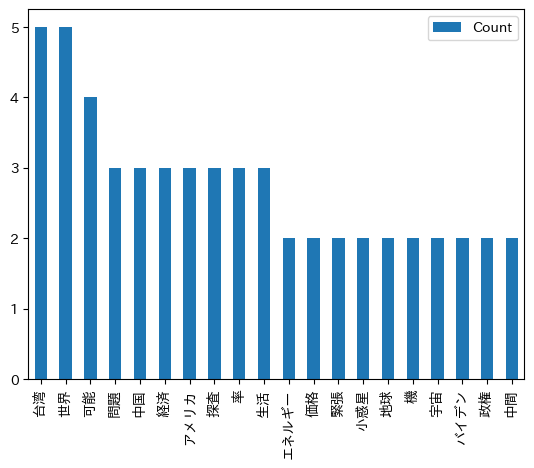

In [ ]:
#####写経#####
df_filtered[:20].plot(kind='bar')

## <font color=#0e89b2>3.3 ワードクラウドによる可視化</font>

### <font color=#0e89b2>a. ワードクラウドとは？</font>

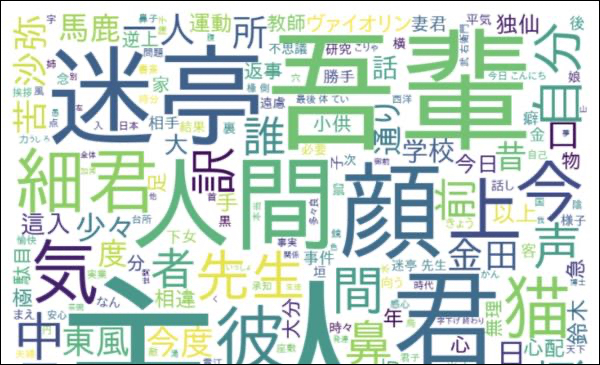

ワードクラウドは、文章中で頻繁に出現する単語を大きく表示することで、内容を視覚的に表現する手法です。<br>
先ほどのような棒グラフで可視化するよりも、より直感的に文章の内容を把握することができます。

### <font color=#0e89b2>b. ワードクラウド描画のためのデータ準備</font>

ワードクラウドの描画は`WordCoud`ライブラリを使うと簡単に行うことができます。<br>
`WordCloud`にデータを渡す時には、以下のような形式になっている必要があります。<br>
`(単語) (単語) (単語) (単語)`<br>
全ての単語の間には半角スペースが入っています。<br>
先ほどの`df_filtered`をこの形式に修正しましょう。

In [ ]:
#####写経#####
words = ""
for i in range(len(df_filtered)):
  word = df_filtered.index[i]
  count = df_filtered["Count"][i]
  words += (word+" ")*count

In [ ]:
#####写経#####
words

'台湾 台湾 台湾 台湾 台湾 世界 世界 世界 世界 世界 可能 可能 可能 可能 問題 問題 問題 中国 中国 中国 経済 経済 経済 アメリカ アメリカ アメリカ 探査 探査 探査 率 率 率 生活 生活 生活 エネルギー エネルギー 価格 価格 緊張 緊張 小惑星 小惑星 地球 地球 機 機 宇宙 宇宙 バイデン バイデン 政権 政権 中間 中間 強化 強化 開発 開発 人類 人類 コロナ コロナ 時代 時代 日本 日本 希望 希望 各国 各国 加速 加速 感染 感染 高騰 高騰 低迷 低迷 選挙 選挙 国民 国民 社会 社会 削減 目標 ガス 効果 排出 再生 温室 洪水 模索 気候 変動 異常 気象 各地 干ばつ 拡大 被害 危機 環境 真剣 きっかけ 投資 具体 2023 対策 分野 人工 知能 医療 教育 製造 業 活用 3 技術 革新 AI 豊か 倫理 安全 懸念 号 いち 講 改選 国内 岸田 内閣 支持 物価 参議院 与党 過半数 サンプル 維持 不満 2 帰還 リュウグウ 貴重 ウィズ 症 薬 11 東アジア 圧力 海峡 自国 領土 一部 主張 武力 統一 姿勢 武器 供与 牽制 米 冷戦 影 終結 戦争 侵攻 歴史 激動 交錯 震撼 ロシア ウクライナ 長期 制裁 犠牲 国際 傷跡 欧米 諸国 構造 治療 共和党 暗闇 光 新型 ウイルス オミクロン 株 出現 増加 重症 死亡 低下 ワクチン 接種 圧迫 人々 直撃 難航 下院 多数 派 奪還 政策 運営 予想 家計 政治 混迷 インフレ 影響 状態 食料 指摘 '

### <font color=#0e89b2>c. ワードクラウドの描画</font>

これでデータの準備が完了しました。<br>
`WordCloud`ライブラリを用いてワードクラウドを描画します。

In [ ]:
# #必要なライブラリをインストール
# !pip install -q wordcloud
# !apt-get -y -qq install fonts-ipafont-gothic

# #ライプラりのインポート
# from wordcloud import WordCloud
# import matplotlib.pyplot as plt
# %matplotlib inline

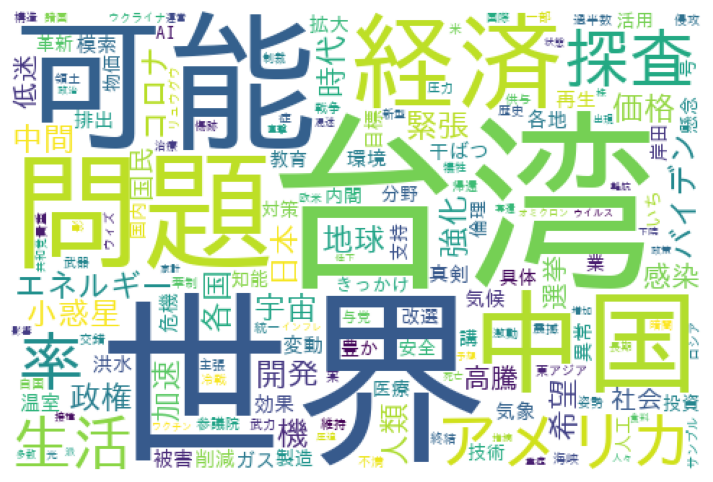

In [ ]:
wc = WordCloud(
                width=480,
                height=320,
                background_color="white",
                font_path='/usr/share/fonts/truetype/fonts-japanese-gothic.ttf'
              )
wc.generate(words)

# ワードクラウドの描画
fig = plt.figure(figsize=(9,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

平文のテキストをそのままワードクラウドで可視化するための関数も準備しておきます。<br>
（必要があれば今後活用してください）

In [ ]:
#ワードクラウドを描画するための関数
def wordcloud_from_plain(text):
  # ワードクラウドの生成
  words = ' '.join([token.surface for token in t.tokenize(text) if token.part_of_speech.split(',')[0] == '名詞'])
  wc = WordCloud(
                  width=480,
                  height=320,
                  background_color="white",
                  font_path='/usr/share/fonts/truetype/fonts-japanese-gothic.ttf'
                )
  wc.generate(words)

  # ワードクラウドの描画
  fig = plt.figure(figsize=(9,6))
  plt.imshow(wc)
  plt.axis("off")
  plt.show()

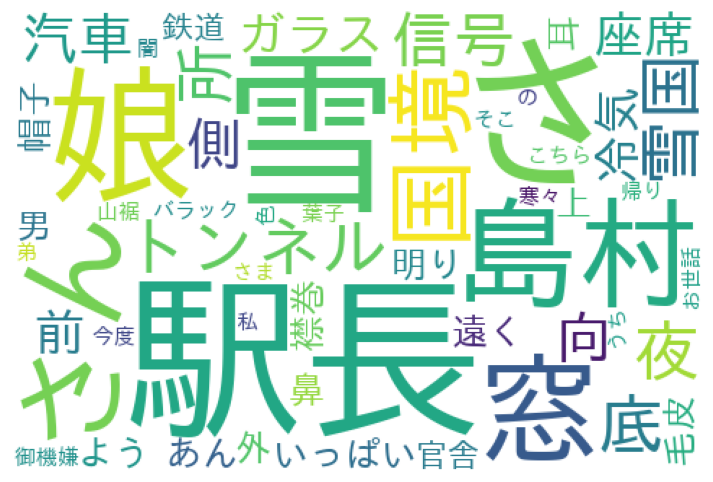

In [ ]:
text = """
国境の長いトンネルを抜けると雪国であった。夜の底が白くなった。信号所に汽車が止まった。
　向側の座席から娘が立って来て、島村の前のガラス窓を落した。雪の冷気が流れこんだ。娘は窓いっぱいに乗り出して、遠くへ呼ぶように、
「駅長さあん、駅長さあん」
　明りをさげてゆっくり雪を踏んで来た男は、襟巻で鼻の上まで包み、耳に帽子の毛皮を垂れていた。
　もうそんな寒さかと島村は外を眺めると、鉄道の官舎らしいバラックが山裾に寒々と散らばっているだけで、雪の色はそこまで行かぬうちに闇に呑まれてい　た。
「駅長さん、私です、御機嫌よろしゅうございます」
「ああ、葉子さんじゃないか。お帰りかい。また寒くなったよ」
「弟が今度こちらに勤めさせていただいておりますのですってね。お世話さまですわ」
"""
wordcloud_from_plain(text)

## <font color=#0e89b2>3.4 Bag of Wordsへの変換</font>

### <font color=#0e89b2>a. Bag of Wordsとは？</font>

ここでは<font color=#f27405>Bag of Words</font>という方法を使います。<br>
Bag of Wordsでは、文章を単語に分割し、それぞれの単語がそれぞれ何回出現したかを数えます。<br>
<br>
ここまでは先ほどと同じですが、Bag of Wordsはこの単語の出現数に基づいて、文章をベクトルとして表します。<br><br>
下の図をご覧ください。<br>
「ベクトル化」のところに入っている数値は、ただの単語の出現回数です。<br>
<br>
これで文章が数値データに変換されたので、機械学習モデルなどで扱えるようになります。

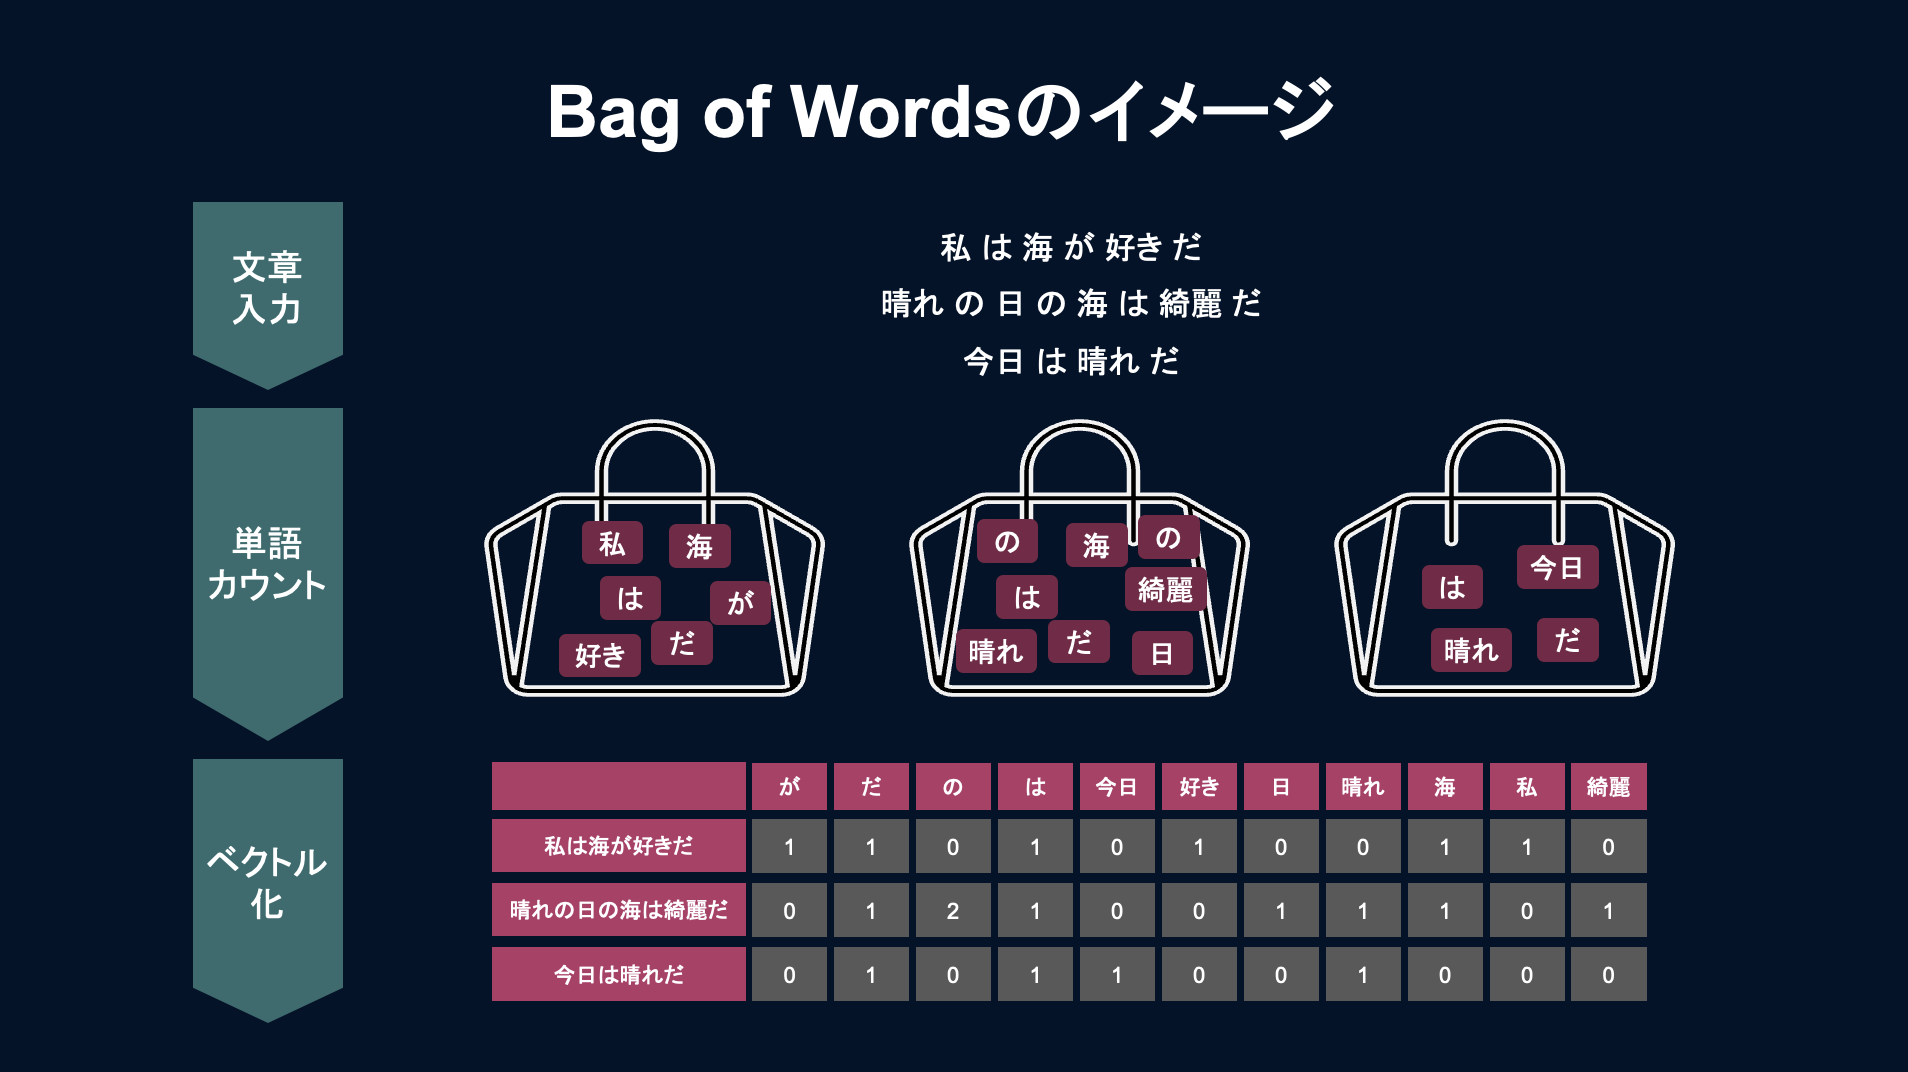

### <font color=#0e89b2>b. Bag of Wordsの実装</font>

まずは必要なライブラリをインポートします。<br>
ここでは、`CountVectorizer`というsklearnのライブラリを使用します。

In [ ]:
# #ライブラリのインポート
# from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
lines = ["私 は 海 が 好き だ", "晴れ の 日 の 海 は 綺麗 だ", "今日 は 晴れ だ"]

In [ ]:
#####写経#####
#単語カウンターの作成
#token_patternは単語の抽出条件。ここでは、スペース以外の文字が1文字以上続いたもの
#min_df=nはn回以下しか出現しない単語は無視（今回は全ての単語を対象とする）
count = CountVectorizer(token_pattern=r'[^\s]+', min_df=0)

#文書からBag of Wordsを作成
bow = count.fit_transform(lines)

#ベクトル化
vec = bow.toarray()
vec

array([[1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0],
       [0, 1, 2, 1, 0, 0, 1, 1, 1, 0, 1],
       [0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0]])

これでBag of Wordsによる文章のベクトル化が完了しています。<br>
もう少し見やすいように出力してみます。

In [ ]:
print('---- 単語リスト ----')
print(sorted(count.vocabulary_.items(), key=lambda x:x[1]))
print('')
print('---- 各文書のベクトル ----')
for i in range(len(lines)):
    print(lines[i], ':\t', vec[i])

---- 単語リスト ----
[('が', 0), ('だ', 1), ('の', 2), ('は', 3), ('今日', 4), ('好き', 5), ('日', 6), ('晴れ', 7), ('海', 8), ('私', 9), ('綺麗', 10)]

---- 各文書のベクトル ----
私 は 海 が 好き だ :	 [1 1 0 1 0 1 0 0 1 1 0]
晴れ の 日 の 海 は 綺麗 だ :	 [0 1 2 1 0 0 1 1 1 0 1]
今日 は 晴れ だ :	 [0 1 0 1 1 0 0 1 0 0 0]


# <font color=#0e89b2>4. 総合問題1：スパムメール判定</font>

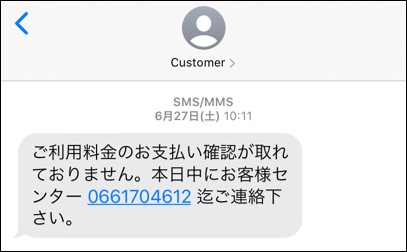

皆様誰しも、この画像のようなスパムメール（メッセージ）を受け取った経験があると思います。<br>
ここでは、このようなスパムメールの自動判定の機能を実装していきます。<br>
<br>
◆スパムメールとは？<br>
* 受信者の意向を無視して一方的に送り付けられるメールのこと。
* 迷惑メールとも呼ばれる。
* 商品の宣伝を目的とするものや、フィッシングサイトへの誘導を目的とするものなど、様々な種類が存在。<br>
<br>

◆ちなみに・・スパムメールの語源は？
* 「スパム」の語源は、あの缶詰のスパム。
* 迷惑メールがスパムと呼ばれるようになったきっかけは、イギリスの人気コメディ番組『空飛ぶモンティ・パイソン』。
 * 夫婦がレストランに来ると、なぜかすべてのメニューにスパムが入っており、まわりの客も「スパム、スパム、スパム」と叫び始める……。
 * このコメディのあと、ハッカーたちが迷惑行為を「スパム」と呼ぶようになり、一般にまで広がった。
* 「スパム」に対して、普通のメールのことを「ハム」と呼ぶこともある。




こちらのファイルをダウンロードして、Pandasデータフレームで読み込んでください。<br>
https://drive.google.com/file/d/11G496e7IRm7ZHNW0eQOyzSFO4MWjjliL/view?usp=drive_link<br>
<br>
なおこちらのデータは、以下のHPで公開されている英語のスパムメールのデータセットを日本語訳したものです。
https://archive.ics.uci.edu/dataset/228/sms+spam+collection

In [ ]:
#データ読み込み
df = pd.read_csv("/content/spam.csv")

#表示
df.head()

,ham/spam,English,日本語,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",ジュロンポイントまで行って、クレイジー... BugisとGreat World La e ...,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,オーケー、ラー...。冗談だよ。,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,2005年5月21日に行われるFAカップ決勝戦の優勝をかけた週2回のコンペに無料で参加できる...,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,そんなに早く言うなよ...。もう言ってるよ...,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",いや、彼がusfに行くとは思わない。,NaN,NaN


## <font color=#0e89b2>4.1 総合問題1.1：データの前処理</font>

### <font color=#0e89b2>(1) データフレームの整理</font>

以下の処理を行って下さい。
* "Unnamed: 3", "Unnamed: 4", "English"の列を削除
 * ヒント：`df.drop()`
* "ham/spam"列の列名を"class"に変更
 * ヒント：`df.rename()`
* 日本語の列が欠損になっている行を削除
 * ヒント：`df.dropna()`

解答

In [ ]:
#Unnamedの列とEnglishの列を削除
df.drop(['English', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

#日本語の列が欠損になっている行を削除
df= df.dropna(subset=['日本語'])

#ham/spamの列名をclassに変更
df.rename(columns={"ham/spam":"class"}, inplace=True)

#表示
df.head()

<ipython-input-300-9806043663a7>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"ham/spam":"class"}, inplace=True)


,class,日本語
0,ham,ジュロンポイントまで行って、クレイジー... BugisとGreat World La e ...
1,ham,オーケー、ラー...。冗談だよ。
2,spam,2005年5月21日に行われるFAカップ決勝戦の優勝をかけた週2回のコンペに無料で参加できる...
3,ham,そんなに早く言うなよ...。もう言ってるよ...
4,ham,いや、彼がusfに行くとは思わない。


### <font color=#0e89b2>(2) 名詞の抽出</font>

「日本語」カラムの文章から名詞のみを抽出して、新しく作成した「名詞」列に格納して下さい。<br>
なお格納する際は、リスト形式にしてください。<br>
<br>
完成イメージはこちらです。<br>
ヒント；`df.apply()`

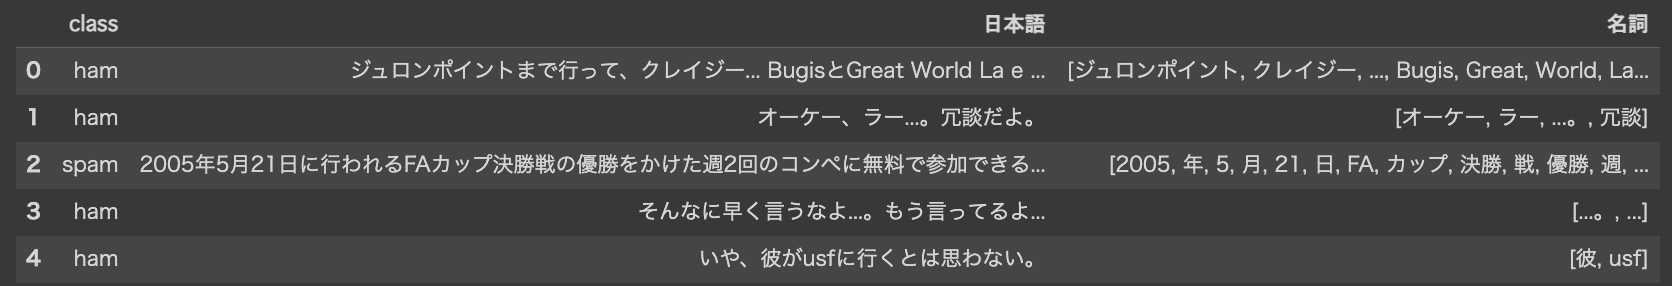

解答

In [ ]:
def extract_nouns(text):
  #形態素解析を実行
  tokens = t.tokenize(text)

  #名詞のみを抽出した単語リストを作成
  words = []
  for line in tokens:
      tkn = re.split('\t|,', str(line))
      #名詞のみを抽出
      if tkn[1] in ['名詞'] :
          words.append(tkn[0])
  return words

In [ ]:
df['名詞'] = df['日本語'].apply(extract_nouns)
df.head()

,class,日本語,名詞
0,ham,ジュロンポイントまで行って、クレイジー... BugisとGreat World La e ...,"[ジュロンポイント, クレイジー, ..., Bugis, Great, World, La..."
1,ham,オーケー、ラー...。冗談だよ。,"[オーケー, ラー, ...。, 冗談]"
2,spam,2005年5月21日に行われるFAカップ決勝戦の優勝をかけた週2回のコンペに無料で参加できる...,"[2005, 年, 5, 月, 21, 日, FA, カップ, 決勝, 戦, 優勝, 週, ..."
3,ham,そんなに早く言うなよ...。もう言ってるよ...,"[...。, ...]"
4,ham,いや、彼がusfに行くとは思わない。,"[彼, usf]"


### <font color=#0e89b2>(3)ストップワードの除去</font>

(2)で作成した「名詞」カラムのリストの中から、ストップワードを除去して下さい。<br>
なおストップワードは、3.2でダウンロードした「ストップワード.csv」ファイルに記載されている単語とします。

解答

In [ ]:
#ストップワードのリストを作成（pd.Seriesからlistへ変換）
stopwords_list = stopwords.tolist()

#ストップワードを除去する関数
def remove_stopwords(noun_list):
    return [noun for noun in noun_list if noun not in stopwords_list]

#'名詞'カラムのリストからストップワードを除去する処理を修正して実行
df['名詞'] = df['名詞'].apply(remove_stopwords_correct)

#表示
df.head()

,class,日本語,名詞
0,ham,ジュロンポイントまで行って、クレイジー... BugisとGreat World La e ...,"[ジュロンポイント, クレイジー, ..., Bugis, Great, World, La..."
1,ham,オーケー、ラー...。冗談だよ。,"[オーケー, ラー, ...。, 冗談]"
2,spam,2005年5月21日に行われるFAカップ決勝戦の優勝をかけた週2回のコンペに無料で参加できる...,"[2005, 5, 21, FA, カップ, 決勝, 戦, 優勝, 2, コンペ, 無料, ..."
3,ham,そんなに早く言うなよ...。もう言ってるよ...,"[...。, ...]"
4,ham,いや、彼がusfに行くとは思わない。,[usf]


In [ ]:
#ストップワードリストの読み込み
stopwords = pd.read_csv("/content/ストップワード.csv")
stopwords = stopwords["ストップワード"]
stopwords

0      あそこ
1      あたり
2      あちら
3      あっち
4       あと
      ... 
309    向こう
310     何人
311     手段
312     同じ
313     感じ
Name: ストップワード, Length: 314, dtype: object

## <font color=#0e89b2>4.2 総合問題1.2：データの可視化</font>

spamメールに含まれる名詞、hamメールに含まれる名詞を、それぞれワードクラウドで可視化してください。

解答

In [ ]:
spam = df[df["class"]=="spam"]
ham = df[df["class"]=="ham"]

In [ ]:
def list_to_text(df):
  words = ""
  for i in df["名詞"]:
    for j in i:
      words += j
      words += " "
  return words

In [ ]:
spam_words = list_to_text(spam)
ham_words = list_to_text(ham)

In [ ]:
def wordcloud(words):
  wc = WordCloud(
                  width=480,
                  height=320,
                  background_color="white",
                  font_path='/usr/share/fonts/truetype/fonts-japanese-gothic.ttf'
                )
  wc.generate(words)

  # ワードクラウドの描画
  fig = plt.figure(figsize=(9,6))
  plt.imshow(wc)
  plt.axis("off")
  plt.show()

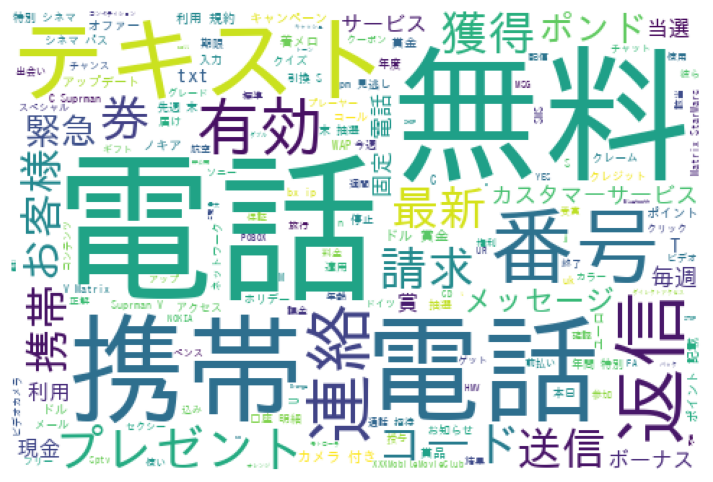

In [ ]:
wordcloud(spam_words)

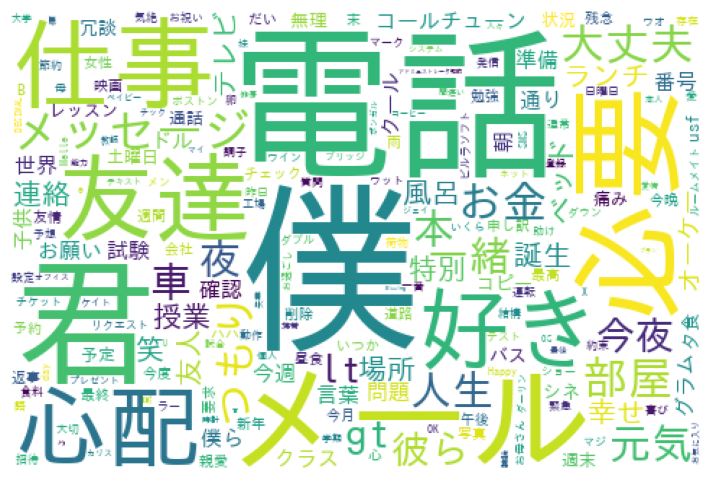

In [ ]:
wordcloud(ham_words)

「電話」のようにspamにもhamにも入っている単語がある一方で、<br>
「無料」「プレゼント」のように、spamに特有の単語も存在することがわかります。

## <font color=#0e89b2>4.3 総合問題1.3：機械学習によるスパムメール判定</font>

### <font color=#0e89b2>(1) Bag of Wordsによるベクトル化</font>



"名詞"列の単語をBag of Wordsでベクトル化して下さい。<br>
なお、最小出現回数（min_df)は3回で設定して下さい。<br>
完成イメージはこちらです。

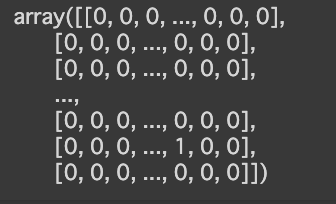

解答

In [ ]:
df['名詞'] = df['名詞'].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
df.head()

,class,日本語,名詞
0,ham,ジュロンポイントまで行って、クレイジー... BugisとGreat World La e ...,ジュロンポイント クレイジー ... Bugis Great World La e Buff...
1,ham,オーケー、ラー...。冗談だよ。,オーケー ラー ...。 冗談
2,spam,2005年5月21日に行われるFAカップ決勝戦の優勝をかけた週2回のコンペに無料で参加できる...,2005 5 21 FA カップ 決勝 戦 優勝 2 コンペ 無料 参加 FA 87121 ...
3,ham,そんなに早く言うなよ...。もう言ってるよ...,...。 ...
4,ham,いや、彼がusfに行くとは思わない。,usf


In [ ]:
#単語カウンターの作成
count = CountVectorizer(token_pattern=r'[^\s]+', min_df=3)

#文書からBag of Wordsを作成
bow = count.fit_transform(df["名詞"])

#ベクトル化
vec = bow.toarray()
vec

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

ちなみに、上のarrayで見てもよくわかりませんが、<br>
下のように各単語の出現回数がカウントされています。

In [ ]:
#学習データの各メールのベクトルを表示
Count_Vecter_df = pd.DataFrame(vec, columns=count.get_feature_names_out())
Count_Vecter_df.head(10)

,"""",&,(,),*,-,.,...,......,...。,...,通話,連絡,週末,週間,適用,部屋,雨,電話,風呂,～
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,1,0,0,0,...,0,1,0,1,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0


### <font color=#0e89b2>(2) 学習データとテストデータの分割</font>

このデータは全部で598行分あります。<br>
先頭の500行を学習データ、それ以降をテストデータとして分割してください。<br>
* x_train：(1)で作成したarrayの先頭500行
* y_train：(1)で作成したarrayの501行目以降
* x_test：df["class"]の先頭500行
* y_train：df["class"]の501行目以降

解答

In [ ]:
x_train = vec[:500]
y_train= df["class"][:500]

x_test = vec[500:]
y_test= df["class"][500:]

念の為スパムとハムの比率を確認しておきます。

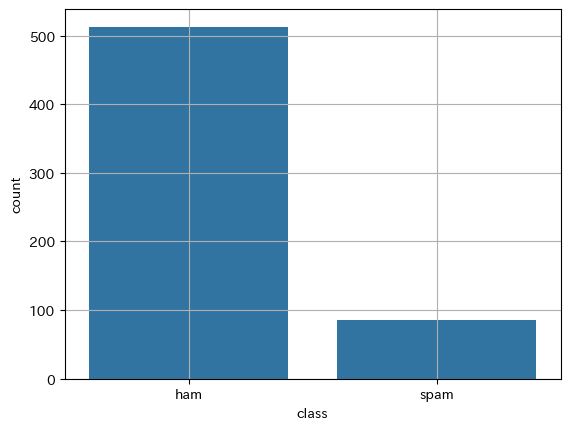

In [ ]:
#棒グラフを表示
sns.countplot(df, x="class")
plt.grid(True)
plt.show()

データを分割します。

In [ ]:
train = df[:500]
test = df[500:]

In [ ]:
test.head()

,class,日本語,名詞
502,ham,しばらく電話していなかったね。マラリアだったんだ。僕はバニに会いたいんだ。良い一日を,電話 マラリア 僕 バニ
503,ham,こんにちは！今日はどうだった？仕事の手がかりがつかめたかな？君のことを想い、海の向こうから熱...,仕事 手がかり 君 海 キス
504,ham,しばらくここにいることになるだろう。,
505,ham,あるいは、私の太い指がボタンを押しまくって、何をすればいいのかわからなくなっているのかもしれない。,指 ボタン
506,ham,今日もたくさんの幸せが返ってくるよ。お誕生日おめでとう。,幸せ 誕生


含まれるスパムデータの比率に偏りがないかも念のため確認しておきます。

In [ ]:
print("学習データに含まれるスパムデータの比率:", len(train[train["class"]=="spam"]) / len(train))
print("学習データに含まれるスパムデータの比率:", len(test[test["class"]=="spam"]) / len(test))

学習データに含まれるスパムデータの比率: 0.142
学習データに含まれるスパムデータの比率: 0.14285714285714285


偏りはなさそうです。

In [ ]:
#学習データの各メールのベクトルを表示
Count_Vecter_df = pd.DataFrame(vec, columns=count.get_feature_names_out())
Count_Vecter_df.head(10)

,"""",&,(,),*,-,.,...,......,...。,...,通話,連絡,週末,週間,適用,部屋,雨,電話,風呂,～
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,1,0,0,0,...,0,1,0,1,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0


### <font color=#0e89b2>(3) ナイーブベイズモデルによるスパム判定</font>

ナイーブベイズモデルでスパム判定を行って下さい。<br>
先ほど分割した学習データとテストデータを使って、正解率を算出してみましょう。<br>
`from sklearn.naive_bayes import BernoulliNB`<br>
`model = BernoulliNB()`

解答

In [ ]:
# #ライブラリのインポート
# from sklearn.naive_bayes import BernoulliNB

#ベルヌーイナイーブベイズモデルを利用（2値分類）
model = BernoulliNB()

#学習用データで学習
model.fit(x_train, y_train)

BernoulliNB()

In [ ]:
#予測結果のスコアを表示
model.score(x_test, y_test)

0.9693877551020408

96.9%と良好な結果です。

混同行列も求めてみましょう。

In [ ]:
#sklearnのconfusion_matrixで混同行列を求める
result = model.predict(x_test)
cm = confusion_matrix(y_test, result)

#列ラベル名
columns_labels = ['ハム(予測)','スパム(予測)']

#行ラベル名
index_labels = ['ハム(正解)','スパム(正解)']

#混同行列をpandasデータフレームに格納
cm = pd.DataFrame(cm, columns=columns_labels, index=index_labels)

#マークダウン書式で表示
print(cm.to_markdown())

|              |   ハム(予測) |   スパム(予測) |
|:-------------|-------------:|---------------:|
| ハム(正解)   |           84 |              0 |
| スパム(正解) |            3 |             11 |


ハムと予測したメールの中に、３通のスパムメールが含まれているようです。<br>
見逃してしまったメールを見てみましょう。<br>


In [ ]:
#テストデータのデータフレームに予測結果の列を追加
test["予測"] = result

#classのカラムと予測のカラムが異なる行だけを抽出
df_incorrect = test[test["class"] != test["予測"]]

#表示
df_incorrect

<ipython-input-267-71a50d9ca0c1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["予測"] = result


,class,日本語,名詞,予測
556,spam,あなたに2000ポンド賞が贈られます！締切前に08712402050までお電話ください。料金...,2000 ポンド 賞 締切 08712402050 電話 料金 10 ポンド,ham
562,spam,重要なカスタマーサービスのお知らせです。今すぐFREEPHONE 0800 542 0825...,重要 カスタマーサービス お知らせ FREEPHONE 0800 542 0825 電話,ham
590,spam,本日、ボーダフォンの4882で終わる番号が350特典の対象となります。該当する方は09064...,本日 ボーダフォン 4882 番号 350 特典 対象 該当 09064019014 電話,ham


「賞」や「特典」などの単語でスパムと判定されそうですが、見逃されてしまっています。<br>
よりデータ数を増やせば、正確にスパムと判定できるかもしれません。

新しいメールでもスパム判定をしてみましょう。<bt>

In [ ]:
def spam_detection(text):
  #名詞の抽出
  text = extract_nouns(text)

  #ストップワードの除去
  text = remove_stopwords(text)

  #リスト形式から文字列形式に変換
  text = " ".join(text)

  #Siries形式に変換（CountVectorizer関数に渡すため）
  text = pd.Series(text)

  #文書からBag of Wordsを作成
  bow = count.transform(text)

  #ベクトル化
  vec = bow.toarray()

  #判定
  return model.predict(vec)

In [ ]:
text = "明日は晴れそうだね。楽しみにしてるよ！"
spam_detection(text)

array(['ham'], dtype='<U4')

In [ ]:
text = "当選おめでとうございます！無料で500ポイントをプレゼントします。こちらのURLからアクセスしてください"
spam_detection(text)

array(['spam'], dtype='<U4')